In [1]:
# %%capture
# !pip install ultralytics

In [2]:
# %%capture
# !pip install "numpy<2.0"

In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
print("torch version:", torch.__version__)
print("torch cuda version:", torch.version.cuda)

import sys
print("Python path:", sys.executable)

import cv2
print("OpenCV version:", cv2.__version__)


CUDA available: True
device: cuda
torch version: 2.5.1+cu121
torch cuda version: 12.1
Python path: c:\Users\Sistem Cerdas Five\Desktop\vian\afre\venv\Scripts\python.exe
OpenCV version: 4.12.0


In [4]:
import numpy as np

print(np.__version__)

2.2.6


In [5]:
import os
import random
import cv2
import math
import time
import torch
import torchvision
import torch.cuda.amp

import numpy as np
import pandas as pd
import torch.nn as nn
import torchvision.transforms as T
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from math import log
from shutil import copy2
from skimage.metrics import structural_similarity
from __future__ import annotations
from dataclasses import dataclass
from typing import Any, Union, Tuple, Dict, List, Optional, Iterator
from tqdm import tqdm
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.ops import nms
from torch.optim import AdamW
from ultralytics import YOLO
from ultralytics.nn.tasks import DetectionModel
from ultralytics.nn.modules import Detect

torch.backends.cudnn.benchmark = True


# CLASSES_FILE = '/kaggle/input/classnames/class_names.txt'
CLASSES_FILE = r'archive\class_names.txt'
BATCH_SIZE=8

# base_train = '/kaggle/input/loli-augmented/train'
base_train = r'archive\train'
train_gt_img = os.path.join(base_train, 'high')
train_low_img = os.path.join(base_train, 'low')
train_yolo_lbls = os.path.join(base_train, 'labels')

# base_val = '/kaggle/input/loli-augmented/val'
base_val = r'archive\val'
val_gt_img = os.path.join(base_val, 'high')
val_low_img = os.path.join(base_val, 'low')
val_yolo_lbls = os.path.join(base_val, 'labels')

# base_test = '/kaggle/input/loli-augmented/test'
base_test = r'archive\test'
test_gt_img = os.path.join(base_test, 'high')
test_low_img = os.path.join(base_test, 'low')
test_yolo_lbls = os.path.join(base_test, 'labels')


print(len(os.listdir(train_gt_img)), len(os.listdir(train_low_img)), len(os.listdir(train_yolo_lbls)))
print(len(os.listdir(val_gt_img)), len(os.listdir(val_low_img)), len(os.listdir(val_yolo_lbls)))
print(len(os.listdir(test_gt_img)), len(os.listdir(test_low_img)), len(os.listdir(test_yolo_lbls)))

6000 6000 6000
600 600 600
300 300 300


In [6]:
def autopad(kernel_size:int, padding:int=None):
    """
    Calculate padding size automatically
    """
    if padding is None:
        return kernel_size // 2 if isinstance(kernel_size, int) else [k // 2 for k in kernel_size]
    return padding

def dist2bbox(distance:torch.Tensor, anchor_points:torch.Tensor, xywh:bool=True, dim:int=-1):
    """
    Transform distance in (ltrb) to bounding box (xywh) or (xyxy)
    """

    lt, rb = torch.chunk(distance, 2, dim=dim)
    xy_lt = anchor_points - lt
    xy_rb = anchor_points + rb

    if xywh:
        center = (xy_lt + xy_rb) / 2
        wh = xy_rb - xy_lt
        return torch.cat((center, wh), dim=dim)
    
    return torch.cat((xy_lt, xy_rb), dim=dim)

def bbox2dist(bbox:torch.Tensor, anchor_points:torch.Tensor, reg_max:int):
    """
    Transform bounding box (xyxy) to distance (ltrb)
    """
    xy_lt, xy_rb = torch.chunk(bbox, 2, dim=-1)
    lt = anchor_points - xy_lt
    rb = xy_rb - anchor_points
    return torch.cat((lt, rb), dim=-1).clamp(max=reg_max-0.01)

def init_weights(model:nn.Module):
    for m in model.modules():
        t = type(m)
        if t is nn.Conv2d:
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif t is nn.BatchNorm2d:
            m.eps = 1e-3
            m.momentum = 0.03
        elif t in (nn.ReLU, nn.SiLU):
            m.inplace = True

def make_anchors(feats:torch.Tensor, strides:torch.Tensor):
    anchor_points = []
    stride_tensor = []

    device = feats[0].device
    dtype = feats[0].dtype

    for i, stride in enumerate(strides):
        h, w = feats[i].shape[-2:]
        yv, xv = torch.meshgrid(torch.arange(h).to(device=device, dtype=dtype) + 0.5,
                                torch.arange(w).to(device=device, dtype=dtype) + 0.5)

        # (x,y) coordinates of center of each cell in grid
        anchor_points.append(torch.stack((xv, yv), dim=-1).view(-1, 2))
        stride_tensor.append(torch.full((h*w,1), stride).to(device=device, dtype=dtype))

    anchor_points = torch.cat(anchor_points, dim=0)
    stride_tensor = torch.cat(stride_tensor, dim=0)

    return anchor_points, stride_tensor

def xywh2xyxy_tensor(xywh:torch.Tensor):
    """
    Convert bounding box coordinates from (xywh) to (xyxy)
    """
    xy, wh = torch.chunk(xywh, 2, dim=-1)
    return torch.cat((xy - wh / 2, xy + wh / 2), dim=-1)

def xyxy2xywh(xyxy:torch.Tensor):
    """
    Convert bounding box coordinates from (xyxy) to (xywh)
    """
    xy_lt, xy_rb = torch.chunk(xyxy, 2, dim=-1)
    return torch.cat(((xy_lt + xy_rb) / 2, xy_rb - xy_lt), dim=-1)

def xywh2xyxy(xywh:np.ndarray):
    """
    Convert bounding box coordinates from (xywh) to (xyxy)
    """
    xy, wh = np.split(xywh, 2, axis=-1)
    return np.concatenate((xy - wh / 2, xy + wh / 2), axis=-1)

def xyxy2xywh(xyxy:np.ndarray):
    """
    Convert bounding box coordinates from (xyxy) to (xywh)
    """
    xy_lt, xy_rb = np.split(xyxy, 2, axis=-1)
    return np.concatenate(((xy_lt + xy_rb) / 2, xy_rb - xy_lt), axis=-1)

def pad_to(x:torch.Tensor, stride:int=None, shape:Tuple[int,int]=None):
    """
    Pads an image with zeros to make it divisible by stride
    (Pads both top/bottom and left/right evenly) or pads to
    specified shape.

    Args:
        x (Tensor): image tensor of shape (..., h, w)
        stride (optional, int): stride of model
        shape (optional, Tuple[int,int]): shape to pad image to
    """
    h, w = x.shape[-2:]

    if stride is not None:
        h_new = h if h % stride == 0 else h + stride - h % stride
        w_new = w if w % stride == 0 else w + stride - w % stride
    elif shape is not None:
        h_new, w_new = shape

    t, b = int((h_new-h) / 2), int(h_new-h) - int((h_new-h) / 2)
    l, r = int((w_new-w) / 2), int(w_new-w) - int((w_new-w) / 2)
    pads = (l, r, t, b)

    x_padded = F.pad(x, pads, "constant", 0)

    return x_padded, pads

def unpad(x:torch.Tensor, pads:tuple):
    l, r, t, b = pads
    return x[..., t:-b, l:-r]

def pad_xyxy(xyxy:Union[np.ndarray, torch.Tensor], pads:Tuple[int, int, int, int], im_size:Tuple[int, int]=None, return_norm:bool=False):
    """
    Add padding to the bounding boxes based on image padding

    Args:
        xyxy: The bounding boxes in the format of `(x_min, y_min, x_max, y_max)`.
            if `im_size` is provided, assume this is normalized coordinates
        pad: The padding added to the image in the format
            of `(left, right, top, bottom)`.
        im_size: The size of the original image in the format of `(height, width)`.
        return_norm: Whether to return normalized coordinates
    """
    l, r, t, b = pads
    if return_norm and im_size is None:
        raise ValueError("im_size must be provided if return_norm is True")
    
    if im_size is not None:
        h, w = im_size
        hpad, wpad = h+b+t, w+l+r
    
    if isinstance(xyxy, np.ndarray):
        xyxy_unnorm = xyxy * np.array([w, h, w, h], dtype=xyxy.dtype) if im_size else xyxy
        padded = xyxy_unnorm + np.array([l, t, l, t], dtype=xyxy.dtype)
        if return_norm:
            padded /= np.array([wpad, hpad, wpad, hpad], dtype=xyxy.dtype)
        return padded
    
    xyxy_unnorm = xyxy * torch.tensor([w, h, w, h], dtype=xyxy.dtype, device=xyxy.device) if im_size else xyxy
    padded = xyxy_unnorm + torch.tensor([l, t, l, t], dtype=xyxy.dtype, device=xyxy.device)
    if return_norm:
        padded /= torch.tensor([wpad, hpad, wpad, hpad], dtype=xyxy.dtype, device=xyxy.device)
    return padded

def pad_xywh(xywh:Union[np.ndarray, torch.Tensor], pads:Tuple[int, int, int, int], im_size:Tuple[int, int]=None, return_norm:bool=False):
    """
    Add padding to the bounding boxes based on image padding

    Args:
        xywh: The bounding boxes in the format of `(x, y, w, h)`.
            if `im_size` is provided, assume this is normalized coordinates
        pad: The padding added to the image in the format
            of `(left, right, top, bottom)`.
        im_size: The size of the original image in the format of `(height, width)`.
        return_norm: Whether to return normalized coordinates
    """
    l, r, t, b = pads
    if return_norm and im_size is None:
        raise ValueError("im_size must be provided if return_norm is True")
    
    if im_size is not None:
        h, w = im_size
        hpad, wpad = h+b+t, w+l+r

    if isinstance(xywh, np.ndarray):
        xywh_unnorm = xywh * np.array([w, h, w, h], dtype=xywh.dtype) if im_size else xywh
        padded = xywh_unnorm + np.array([l, t, 0, 0], dtype=xywh.dtype)
        if return_norm:
            padded /= np.array([wpad, hpad, wpad, hpad], dtype=xywh.dtype)
        return padded
    
    xywh_unnorm = xywh * torch.tensor([w, h, w, h], dtype=xywh.dtype, device=xywh.device) if im_size else xywh
    padded = xywh_unnorm + torch.tensor([l, t, 0, 0], dtype=xywh.dtype, device=xywh.device)
    if return_norm:
        padded /= torch.tensor([wpad, hpad, wpad, hpad], dtype=xywh.dtype, device=xywh.device)
    return padded

def unpad_xyxy(xyxy:Union[np.ndarray, torch.Tensor], pads:Tuple[int, int, int, int]):
    """
    Remove padding from the bounding boxes based on image padding

    Args:
        pad: The padding added to the image in the format
            of `(left, right, top, bottom)`.
    """
    l, r, t, b = pads
    if isinstance(xyxy, np.ndarray):
        return xyxy - np.array([l, t, l, t], dtype=xyxy.dtype)
    return xyxy - torch.tensor([l, t, l, t], dtype=xyxy.dtype, device=xyxy.device)

def box_iou_batch(gt_boxes: np.ndarray, pred_boxes: np.ndarray) -> np.ndarray:
    """
    Compute Intersection over Union (IoU) of two sets of bounding boxes -
        `gt_boxes` and `pred_boxes`. Both sets
        of boxes are expected to be in `(xyxy)` format.

    Args:
        gt_boxes (np.ndarray): 2D `np.ndarray` representing ground-truth boxes.
            `shape = (N, 4)` where `N` is number of true objects.
        pred_boxes (np.ndarray): 2D `np.ndarray` representing detection boxes.
            `shape = (M, 4)` where `M` is number of detected objects.

    Returns:
        np.ndarray: Pairwise IoU of boxes from `gt_boxes` and `pred_boxes`.
            `shape = (N, M)` where `N` is number of true objects and
            `M` is number of detected objects.
    """

    def box_area(box):
        return (box[2] - box[0]) * (box[3] - box[1])

    area_true = box_area(gt_boxes.T)
    area_detection = box_area(pred_boxes.T)

    top_left = np.maximum(gt_boxes[:, None, :2], pred_boxes[:, :2])
    bottom_right = np.minimum(gt_boxes[:, None, 2:], pred_boxes[:, 2:])

    area_inter = np.prod(np.clip(bottom_right - top_left, a_min=0, a_max=None), 2)
    return area_inter / (area_true[:, None] + area_detection - area_inter)

def non_max_suppression(predictions: np.ndarray, iou_threshold: float = 0.5) -> np.ndarray:
    """
    Perform Non-Maximum Suppression (NMS) on object detection predictions.

    Args:
        predictions (np.ndarray): An array of object detection predictions in
            the format of `(x_min, y_min, x_max, y_max, score)`
            or `(x_min, y_min, x_max, y_max, score, class)`.
        iou_threshold (float, optional): The intersection-over-union threshold
            to use for non-maximum suppression.

    Returns:
        np.ndarray: A boolean array indicating which predictions to keep after n
            on-maximum suppression.

    Raises:
        AssertionError: If `iou_threshold` is not within the
            closed range from `0` to `1`.
    """
    assert 0 <= iou_threshold <= 1, (
        "Value of `iou_threshold` must be in the closed range from 0 to 1, "
        f"{iou_threshold} given."
    )
    rows, columns = predictions.shape

    # add column #5 - category filled with zeros for agnostic nms
    if columns == 5:
        predictions = np.c_[predictions, np.zeros(rows)]

    # sort predictions column #4 - score
    sort_index = np.flip(predictions[:, 4].argsort())
    predictions = predictions[sort_index]

    boxes = predictions[:, :4]
    categories = predictions[:, 5]
    ious = box_iou_batch(boxes, boxes)
    ious = ious - np.eye(rows)

    keep = np.ones(rows, dtype=bool)

    for index, (iou, category) in enumerate(zip(ious, categories)):
        if not keep[index]:
            continue

        # drop detections with iou > iou_threshold and
        # same category as current detections
        condition = (iou > iou_threshold) & (categories == category)
        keep = keep & ~condition

    return keep[sort_index.argsort()]

### Data validation for Detections class
def validate_xyxy(xyxy:Any) -> None:
    expected_shape = "(_, 4)"
    actual_shape = str(getattr(xyxy, "shape", None))
    is_valid = isinstance(xyxy, np.ndarray) and xyxy.ndim == 2 and xyxy.shape[1] == 4
    if not is_valid:
        raise ValueError(
            f"xyxy must be a 2D np.ndarray with shape {expected_shape}, but got shape "
            f"{actual_shape}"
        )

def validate_mask(mask:Any, n:int) -> None:
    expected_shape = f"({n}, H, W)"
    actual_shape = str(getattr(mask, "shape", None))
    is_valid = mask is None or (
        isinstance(mask, np.ndarray) and len(mask.shape) == 3 and mask.shape[0] == n
    )
    if not is_valid:
        raise ValueError(
            f"mask must be a 3D np.ndarray with shape {expected_shape}, but got shape "
            f"{actual_shape}"
        )

def validate_class_id(class_id:Any, n:int) -> None:
    expected_shape = f"({n},)"
    actual_shape = str(getattr(class_id, "shape", None))
    is_valid = class_id is None or (
        isinstance(class_id, np.ndarray) and class_id.shape == (n,)
    )
    if not is_valid:
        raise ValueError(
            f"class_id must be a 1D np.ndarray with shape {expected_shape}, but got "
            f"shape {actual_shape}"
        )

def validate_confidence(confidence:Any, n:int) -> None:
    expected_shape = f"({n},)"
    actual_shape = str(getattr(confidence, "shape", None))
    is_valid = confidence is None or (
        isinstance(confidence, np.ndarray) and confidence.shape == (n,)
    )
    if not is_valid:
        raise ValueError(
            f"confidence must be a 1D np.ndarray with shape {expected_shape}, but got "
            f"shape {actual_shape}"
        )

def validate_tracker_id(tracker_id:Any, n:int) -> None:
    expected_shape = f"({n},)"
    actual_shape = str(getattr(tracker_id, "shape", None))
    is_valid = tracker_id is None or (
        isinstance(tracker_id, np.ndarray) and tracker_id.shape == (n,)
    )
    if not is_valid:
        raise ValueError(
            f"tracker_id must be a 1D np.ndarray with shape {expected_shape}, but got "
            f"shape {actual_shape}"
        )

def validate_detections_fields(
    xyxy: Any,
    mask: Any,
    class_id: Any,
    confidence: Any,
    tracker_id: Any
) -> None:
    validate_xyxy(xyxy)
    n = len(xyxy)
    validate_mask(mask, n)
    validate_class_id(class_id, n)
    validate_confidence(confidence, n)
    validate_tracker_id(tracker_id, n)



class LoLiStreetDataset_Direct(Dataset):
    """
    Dataset that directly scans directories for Low, High, and Label files.
    It matches files based on the filename found in the 'high' directory.
    """
    def __init__(self, high_dir: str, low_dir: str, labels_dir: str, img_size: tuple[int, int] = (640, 640), transform=None):
        super().__init__()
        self.img_size = img_size
        self.transform = transform if transform else T.ToTensor()
        
        self.high_images = []
        self.low_images = []
        self.labels_files = []

        # 1. Scan the Ground Truth (High) directory
        valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
        try:
            # Get all image files in high dir
            files = sorted([f for f in os.listdir(high_dir) if f.lower().endswith(valid_extensions)])
        except FileNotFoundError:
            print(f"[Error] Directory not found: {high_dir}")
            files = []

        # 2. Match with Low and Labels
        for f_name in files:
            high_path = os.path.join(high_dir, f_name)
            low_path = os.path.join(low_dir, f_name) # Assumes identical filename
            
            # Construct label path: replace image extension with .txt
            file_stem = os.path.splitext(f_name)[0]
            label_path = os.path.join(labels_dir, file_stem + '.txt')

            # 3. Verify existence of all three components
            if os.path.exists(low_path) and os.path.exists(label_path):
                self.high_images.append(high_path)
                self.low_images.append(low_path)
                self.labels_files.append(label_path)
            else:
                # Optional: Print warning if a pair is missing
                # print(f"Skipping {f_name}: Missing low image or label file.")
                pass

        print(f"Found {len(self.high_images)} valid triplets in {high_dir}")

        # Load all labels initially (Cache)
        self.labels_cache = self._load_all_labels()
        
    def __len__(self):
        return len(self.high_images)

    # --- Unchanged Helper Methods ---

    def _load_labels_for_file(self, label_filepath: str) -> dict:
        labels_list = self._read_yolo_labels(label_filepath) 
        if not labels_list:
            return {'cls': torch.empty(0, dtype=torch.long), 'bboxes': torch.empty(0, 4, dtype=torch.float32)}
        label_tensor = torch.tensor(labels_list, dtype=torch.float32)
        return {'cls': label_tensor[:, 0].long(), 'bboxes': label_tensor[:, 1:5]}

    def _load_all_labels(self):
        return [self._load_labels_for_file(f) for f in self.labels_files]

    def _read_yolo_labels(self, label_filepath: str) -> list[list[float]]:
        labels = []
        if not os.path.exists(label_filepath): return labels
        try:
            with open(label_filepath, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        labels.append([float(p) for p in parts])
        except Exception as e:
            print(f"Warning: Error reading labels from {label_filepath}: {e}") 
        return labels

    def _load_single_image(self, img_path: str):
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        h0, w0 = image.shape[:2]
        
        # Resize
        if h0 > self.img_size[0] or w0 > self.img_size[1]:
            ratio = min(self.img_size[0] / h0, self.img_size[1] / w0)
            h, w = math.ceil(h0 * ratio), math.ceil(w0 * ratio)
            h, w = min(h, self.img_size[0]), min(w, self.img_size[1]) 
            image = cv2.resize(image, (w, h), interpolation=cv2.INTER_LINEAR)
        else:
            h, w = h0, w0
            
        # To Tensor
        image = image.transpose((2, 0, 1)) 
        image_tensor = torch.from_numpy(image).float() / 255.0
        
        padded_image, pads = pad_to(image_tensor, shape=self.img_size)
        
        return padded_image, pads, (h0, w0)

    def __getitem__(self, idx: int):
        low_img_tensor, low_pads, low_orig_shapes = self._load_single_image(self.low_images[idx])
        high_img_tensor, high_pads, high_orig_shapes = self._load_single_image(self.high_images[idx])
        label = self.labels_cache[idx]
        
        # Adjust Bboxes
        # WARNING: Ensure 'pad_xywh' is available in your scope.
        adjusted_bboxes = pad_xywh(
            label['bboxes'], 
            high_pads, 
            high_orig_shapes, 
            return_norm=True 
        )

        return {
            'images_low': low_img_tensor,
            'images_high': high_img_tensor,
            'cls': label['cls'],
            'bboxes': adjusted_bboxes,
            'padding_high': high_pads,
            'orig_shapes_high': high_orig_shapes,
            'im_id': os.path.splitext(os.path.basename(self.high_images[idx]))[0]
        }

# --- Collate Function (Same as before) ---
@staticmethod
def collate_fn(batch: list[dict]):
    collated_batch = {}
    collated_batch['images_high'] = torch.stack([b['images_high'] for b in batch], dim=0)
    collated_batch['images_low'] = torch.stack([b['images_low'] for b in batch], dim=0)
    collated_batch['cls'] = torch.cat([b['cls'] for b in batch], dim=0)
    collated_batch['bboxes'] = torch.cat([b['bboxes'] for b in batch], dim=0)
    for k in ('padding_high', 'orig_shapes_high', 'im_id'):
        collated_batch[k] = [b[k] for b in batch]
    batch_idx_list = [torch.full((batch[i]['cls'].shape[0],), i, dtype=torch.float32) for i in range(len(batch))]
    collated_batch['batch_idx'] = torch.cat(batch_idx_list, dim=0)
    return collated_batch

# --- Execution Block ---

BATCH_SIZE = 8

try:
    data_transform = T.ToTensor() 

    print("Initializing Train Dataset...")
    train_dataset = LoLiStreetDataset_Direct(
        high_dir=train_gt_img, 
        low_dir=train_low_img, 
        labels_dir=train_yolo_lbls, 
        img_size=(640, 640)
    )
    
    print("Initializing Val Dataset...")
    val_dataset = LoLiStreetDataset_Direct(
        high_dir=val_gt_img, 
        low_dir=val_low_img, 
        labels_dir=val_yolo_lbls, 
        img_size=(640, 640)
    )

    print("Initializing Test Dataset...")
    test_dataset = LoLiStreetDataset_Direct(
        high_dir=test_gt_img, 
        low_dir=test_low_img, 
        labels_dir=test_yolo_lbls, 
        img_size=(640, 640)
    )

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0, pin_memory=True)#, persistent_workers=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0, pin_memory=True)#, persistent_workers=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0, pin_memory=True)#, persistent_workers=True)

    print(f"\nSUCCESS: Datasets created. Train size: {len(train_dataset)}")

except Exception as e:
    print(f"\n[ERROR] Failed to initialize datasets: {e}")

Initializing Train Dataset...
Found 6000 valid triplets in archive\train\high
Initializing Val Dataset...
Found 600 valid triplets in archive\val\high
Initializing Test Dataset...
Found 300 valid triplets in archive\test\high

SUCCESS: Datasets created. Train size: 6000


### Model Definition

---

YOLOv8 Clone


References: 
1. https://github.com/jahongir7174/YOLOv8-dfl/tree/master
2. https://arxiv.org/html/2304.00501v6/#S16
3. https://github.com/ultralytics/ultralytics/tree/main/ultralytics/models/yolo
4. https://github.com/dtdo90/yolov8_detection

In [7]:
# return depth, width, ratio based on version
def yolo_params(version): 
    print(f'Initializing {version} params')
    if version == 'nano': 
        return 1/3, 1/4, 2.0
    elif version == 'small': 
        return 1/3, 1/2, 2.0
    elif version == 'medium': 
        return 2/3, 3/4, 1.5
    elif version == 'large': 
        return 1.0, 1.0, 1.0 
    elif version == 'X': 
        return 1.0, 1.25, 1.0
    else: 
        raise(ValueError())
    

class Conv(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=1,
        padding=1,
        groups=1,
        activation=True,
    ):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size,
            stride,
            padding,
            bias=False,
            groups=groups,
        )
        self.bn = nn.BatchNorm2d(out_channels, eps=0.001, momentum=0.03)
        self.act = nn.SiLU(inplace=True) if activation else nn.identity()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))
    

class Bottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, shortcut=True):
        super().__init__()
        self.conv1 = Conv(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.conv2 = Conv(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.shortcut = shortcut

    def forward(self, x):
        x_in = x  # for skip connection
        x = self.conv1(x)
        x = self.conv2(x)
        if self.shortcut:
            x += x_in
        return x


# YOLOV8 C2F Block
# Combines high-level features with contextual information to improve detection acc
# It effectively combines the benefits of two concepts:
# 1. Cross-Stage Partial (CSP) Network: Splits input feature map into 2 branches, where 1 goes thru series of computational layers (bottlenecks) 
#                                       and the other as a bypass. This allows the network to learn both shallow and deep feats simultaneously, 
#                                       enhancing acc and reduce redundant gradient info
# 2. Bottlenecks: The repeating Bottleneck layers allow the model to process features efficiently by compressing the channel dimension before 
#                 applying the main computations, then expanding it again.
# In short: C2f maximizes feature reuse and learning by explicitly combining the results of multiple computational stages within a single block.
class C2f(nn.Module):
    def __init__(self, in_channels, out_channels, num_bottlenecks, shortcut=True):
        super().__init__()
        self.mid_channels = out_channels // 2
        self.num_bottlenecks = num_bottlenecks
        self.shortcut = shortcut
        self.conv1 = Conv(in_channels, out_channels, kernel_size=1, stride=1, padding=0)

        # sequence of bottleneck layers
        self.m = nn.ModuleList(
            [
                Bottleneck(self.mid_channels, self.mid_channels, self.shortcut)
                for _ in range(num_bottlenecks)
            ]
        )

        self.conv2 = Conv(
            (num_bottlenecks + 2) * out_channels // 2,
            out_channels,
            kernel_size=1,
            stride=1,
            padding=0,
        )

    def forward(self, x):
        x = self.conv1(x)

        # split x along channel dimension
        x1, x2 = x[:, : x.shape[1] // 2, :, :], x[:, : x.shape[1] // 2, :, :]

        # list of outputs
        outputs = [x1, x2]  # x1 is fed through the bottlenecks

        for i in range(self.num_bottlenecks):
            x1 = self.m[i](x1)  # [batch_size, 0.5 out_channel, w, h]
            outputs.insert(0, x1)

        outputs = torch.cat(
            outputs, dim=1
        )  # [batch_size, 0.5 out_channel(num_bottlenecks + 2), w, h]
        out = self.conv2(outputs)

        return out
    

class SPPF(nn.Module):
    def __init__(self, in_channels, out_channels, pool_kernel_size=5):
        super().__init__()
        hidden_channel = in_channels // 2

        self.conv1 = Conv(
            in_channels, hidden_channel, kernel_size=1, stride=1, padding=0
        )

        # concatenate output of maxpool and feed to conv2
        self.conv2 = Conv(
            4 * hidden_channel, out_channels, kernel_size=1, stride=1, padding=0
        )

        # maxpool is applied at 3 different scales
        self.maxpool = nn.MaxPool2d(
            kernel_size=pool_kernel_size,
            stride=1,
            padding=pool_kernel_size // 2,
            dilation=1,
            ceil_mode=False,
        )

    def forward(self, x):
        x = self.conv1(x)

        y1 = self.maxpool(x)
        y2 = self.maxpool(y1)
        y3 = self.maxpool(y2)
        y = torch.cat([x, y1, y2, y3], dim=1)

        y = self.conv2(y)

        return y
    

# YOLOv8 Clone Backbone
class BackBone(nn.Module): 
    def __init__(self, version, in_channels=3, shortcut=True):
        super().__init__()
        depth, width, ratio = yolo_params(version)
        
        # conv layers
        self.conv0 = Conv(in_channels, int(64 * width), kernel_size=3, stride=2, padding=1)
        self.conv1 = Conv(int(64 * width), int(128 * width), kernel_size=3, stride=2, padding=1)
        self.conv3 = Conv(int(128 * width), int(256 * width), kernel_size=3, stride=2, padding=1)
        self.conv5 = Conv(int(256 * width), int(512 * width), kernel_size=3, stride=2, padding=1)
        self.conv7 = Conv(int(512 * width), int(512 * width * ratio), kernel_size=3, stride=2, padding=1)
        
        # c2f layers 
        self.c2f_2 = C2f(int(128 * width), int(128 * width), num_bottlenecks=int(3 * depth), shortcut=True)
        self.c2f_4 = C2f(int(256 * width), int(256 * width), num_bottlenecks=int(6 * depth), shortcut=True)
        self.c2f_6 = C2f(int(512 * width), int(512 * width), num_bottlenecks=int(6 * depth), shortcut=True)
        self.c2f_8 = C2f(int(512 * width * ratio), int(512 * width * ratio), num_bottlenecks=int(3 * depth), shortcut=True)
        
        # sppf 
        self.sppf = SPPF(int(512 * width * ratio), int(512 * width * ratio))
        
    def forward(self, x): 
        x = self.conv0(x)
        x = self.conv1(x)
        x = self.c2f_2(x)
        x = self.conv3(x)
        
        out1 = self.c2f_4(x) # keep for output 
        
        x = self.conv5(out1)
        
        out2 = self.c2f_6(x) # keep for output 
        
        x = self.conv7(out2)
        x = self.c2f_8(x)
        
        out3 = self.sppf(x)
        
        return out1, out2, out3


# Custom YOLOv8 Backbone. Returns 4 stages from the backbone
# reference paper requires h/2, h/4 and h/8 for decoding, however to follow YOLO backbone it would make sense to do it after 
# each C2F, as it plays a crucial role in maximizing feature learning
class BackBone_4(nn.Module): 
    def __init__(self, version, in_channels=3, shortcut=True):
        super().__init__()
        depth, width, ratio = yolo_params(version)
        
        # conv layers
        self.conv0 = Conv(in_channels, int(64 * width), kernel_size=3, stride=2, padding=1)
        self.conv1 = Conv(int(64 * width), int(128 * width), kernel_size=3, stride=2, padding=1)
        self.conv3 = Conv(int(128 * width), int(256 * width), kernel_size=3, stride=2, padding=1)
        self.conv5 = Conv(int(256 * width), int(512 * width), kernel_size=3, stride=2, padding=1)
        self.conv7 = Conv(int(512 * width), int(512 * width * ratio), kernel_size=3, stride=2, padding=1)
        
        # c2f layers 
        self.c2f_2 = C2f(int(128 * width), int(128 * width), num_bottlenecks=int(3 * depth), shortcut=True)
        self.c2f_4 = C2f(int(256 * width), int(256 * width), num_bottlenecks=int(6 * depth), shortcut=True)
        self.c2f_6 = C2f(int(512 * width), int(512 * width), num_bottlenecks=int(6 * depth), shortcut=True)
        self.c2f_8 = C2f(int(512 * width * ratio), int(512 * width * ratio), num_bottlenecks=int(3 * depth), shortcut=True)
        
        # sppf 
        self.sppf = SPPF(int(512 * width * ratio), int(512 * width * ratio))
        
    def forward(self, x):

        x = self.conv0(x)              # H/2
        x = self.conv1(x)              # H/4
        
        stem = self.c2f_2(x)           # H/4
        
        x = self.conv3(stem)
        dark2 = self.c2f_4(x)          # H/4

        x = self.conv5(dark2)
        dark3 = self.c2f_6(x)          # H/8

        x = self.conv7(dark3)
        dark4 = self.c2f_8(x)          # H/16

        out = self.sppf(dark4)         # H/32

        return stem, dark2, dark3, out
        
        
# Custom YOLOv8 Backbone. Returns all 5 stages from the backbone
# this backbone follows the paper's requirement of h/2, h/4 and h/8
class BackBone_5(nn.Module): 
    def __init__(self, version, in_channels=3, shortcut=True):
        super().__init__()
        depth, width, ratio = yolo_params(version)
        
        # conv layers
        self.conv0 = Conv(in_channels, int(64 * width), kernel_size=3, stride=2, padding=1)
        self.conv1 = Conv(int(64 * width), int(128 * width), kernel_size=3, stride=2, padding=1)
        self.conv3 = Conv(int(128 * width), int(256 * width), kernel_size=3, stride=2, padding=1)
        self.conv5 = Conv(int(256 * width), int(512 * width), kernel_size=3, stride=2, padding=1)
        self.conv7 = Conv(int(512 * width), int(512 * width * ratio), kernel_size=3, stride=2, padding=1)
        
        # c2f layers 
        self.c2f_2 = C2f(int(128 * width), int(128 * width), num_bottlenecks=int(3 * depth), shortcut=True)
        self.c2f_4 = C2f(int(256 * width), int(256 * width), num_bottlenecks=int(6 * depth), shortcut=True)
        self.c2f_6 = C2f(int(512 * width), int(512 * width), num_bottlenecks=int(6 * depth), shortcut=True)
        self.c2f_8 = C2f(int(512 * width * ratio), int(512 * width * ratio), num_bottlenecks=int(3 * depth), shortcut=True)
        
        # sppf 
        self.sppf = SPPF(int(512 * width * ratio), int(512 * width * ratio))
        
    def forward(self, x):
        stem = self.conv0(x)              # H/2
        x = self.conv1(stem)              # H/2
        
        dark2 = self.c2f_2(x)             # H/4
        
        x = self.conv3(dark2)
        dark3 = self.c2f_4(x)             # H/4
        
        x = self.conv5(dark3)
        dark4 = self.c2f_6(x)             # H/8
        
        x = self.conv7(dark4)
        x = self.c2f_8(x)          # H/16
        
        out = self.sppf(x)         # H/32
        return stem, dark2, dark3, dark4, out
    
    
class Upsample(nn.Module): 
    def __init__(self, scale_factor=2, mode='nearest'):
        super().__init__()
        self.scale_factor = scale_factor
        self.mode = mode 
        
    def forward(self, x): 
        return nn.functional.interpolate(x, scale_factor=self.scale_factor, mode=self.mode)
    

class DFL(nn.Module): 
    def __init__(self, ch=16):
        super().__init__()
        self.ch = ch 
        
        self.conv = nn.Conv2d(in_channels=ch, out_channels=1, kernel_size=1, bias=False).requires_grad_(False)
        x = torch.arange(ch, dtype=torch.float).view(1, ch, 1, 1)
        self.conv.weight.data[:] = torch.nn.Parameter(x) # DFL only has ch parameters
    
    def forward(self, x): 
        # x must have num_channels = 4 * ch, x = [bs, 4 * ch, c]
        b, c, a = x.shape
        x = x.view(b, 4, self.ch, a).transpose(1, 2)
        
        # take softmax on channel dimension ot get dist probabilities 
        x = x.softmax(1)            #[ b, ch, 4, a]
        x = self.conv(x)            #[ b, 1, 4, a]
        return x.view(b, 4, a)      #[ b, 4, a]
    

class Neck(nn.Module): 
    def __init__(self, version):
        super().__init__()
        d, w, r = yolo_params(version)
        
        self.up = Upsample() # no trainable params 
        self.c2f_1 = C2f(in_channels=int(512 * w * (1 + r)), out_channels=int(512 * w), num_bottlenecks=int(3 * d), shortcut=False)
        self.c2f_2 = C2f(in_channels=int(768 * w), out_channels=int(256 * w), num_bottlenecks=int(3 * d), shortcut=False)
        self.c2f_3 = C2f(in_channels=int(768 * w), out_channels=int(512 * w), num_bottlenecks=int(3 * d), shortcut=False)
        self.c2f_4 = C2f(in_channels=int(512 * w * (1 + r)), out_channels=int(512 * w * r), num_bottlenecks=int(3 * d), shortcut=False)
        
        self.conv_1 = Conv(in_channels=int(256 * w), out_channels=int(256 * w), kernel_size=3, stride=2, padding=1)
        self.conv_2 = Conv(in_channels=int(512 * w), out_channels=int(512 * w), kernel_size=3, stride=2, padding=1)
        
    # x_res1, 2, 3 is output from backbone
    # 1 --> 3 = smallest to largest channels
    def forward(self, x_res1, x_res2, x_res3): 
        res1 = x_res3                       # for residual connection 
        
        x = self.up(x_res3)
        x = torch.cat([x, x_res2], dim=1)   # dim=1, --> along channel dimension
        res2 = self.c2f_1(x)                # for residual connection
        x = self.up(res2)
        x = torch.cat([x, x_res1], dim=1)
        
        out1 = self.c2f_2(x)
        
        x = self.conv_1(out1)
        x = torch.cat([x, res2], dim=1)
        
        out2 = self.c2f_3(x)
        
        x = self.conv_2(out2)
        x = torch.cat([x, res1], dim=1)
        
        out3 = self.c2f_4(x)
        
        return out1, out2, out3
    

class Head(nn.Module): 
    def __init__(self, version, ch=16, num_classes=80):
        super().__init__()
        self.ch = ch 
        self.coords = self.ch * 4 
        self.nc = num_classes
        self.no = self.coords + self.nc 
        self.stride = torch.zeros(3) 
        d, w, r = yolo_params(version=version)
        
        # for bounding box
        self.box = nn.ModuleList([
            # 1st det head
            nn.Sequential(
                Conv(int(256 * w), self.coords, kernel_size=3, stride=1, padding=1),
                Conv(self.coords, self.coords, kernel_size=3, stride=1, padding=1), 
                nn.Conv2d(self.coords, self.coords, kernel_size=1, stride=1)
                ),
            
            # 2nd det head
            nn.Sequential(
                Conv(int(512 * w), self.coords, kernel_size=3, stride=1, padding=1),
                Conv(self.coords, self.coords, kernel_size=3, stride=1, padding=1), 
                nn.Conv2d(self.coords, self.coords, kernel_size=1, stride=1)
                ),
            
            # 3rd det head
            nn.Sequential(
                Conv(int(512 * w * r), self.coords, kernel_size=3, stride=1, padding=1),
                Conv(self.coords, self.coords, kernel_size=3, stride=1, padding=1), 
                nn.Conv2d(self.coords, self.coords, kernel_size=1, stride=1)
                ),
        ])
        
        self.cls = nn.ModuleList([
            nn.Sequential(
                Conv(int(256 * w), self.nc, kernel_size=3, stride=1, padding=1),
                Conv(self.nc, self.nc, kernel_size=3, stride=1, padding=1),
                nn.Conv2d(self.nc, self.nc, kernel_size=1, stride=1)
            ),
            nn.Sequential(
                Conv(int(512 * w), self.nc, kernel_size=3, stride=1, padding=1),
                Conv(self.nc, self.nc, kernel_size=3, stride=1, padding=1),
                nn.Conv2d(self.nc, self.nc, kernel_size=1, stride=1)
            ),
            nn.Sequential(
                Conv(int(512 * w * r), self.nc, kernel_size=3, stride=1, padding=1),
                Conv(self.nc, self.nc, kernel_size=3, stride=1, padding=1),
                nn.Conv2d(self.nc, self.nc, kernel_size=1, stride=1)
            ),
        ])
        
        self.dfl = DFL() 
    
    def make_anchors(self, x, strides, offset=0.5): 
        # x = list of feature maps: x=x[0], ..., x[n - 1], in our case n = num_detection_heads = 3, each having shapes [bs, ch, w, h]
        # each feature map x[i] gives output[i] = w * h anchor coords + w * h stride values
        # strides = list of stride values indicating how much the spatial resolution of the feature map is reduced compared to the original image 
        
        assert x is not None 
        anchor_tensor, stride_tensor = [], [] 
        dtype, device = x[0].dtype, x[0].device
        
        for i, stride in enumerate(strides): 
            _, _, h, w = x[i].shape
            sx = torch.arange(end=w, device=device, dtype=dtype) + offset # x coords of anchor centers 
            sy = torch.arange(end=h, device=device, dtype=dtype) + offset # y coords of anchor centers 
            sy, sx = torch.meshgrid(sy, sx)
            anchor_tensor.append(torch.stack((sx, sy), -1).view(-1, 2))
            stride_tensor.append(torch.full((h * w, 1), stride, dtype=dtype, device=device))
        return torch.cat(anchor_tensor), torch.cat(stride_tensor)
        
    def forward(self, x, inference=False): 
        # x = output of Neck = list of 3 tensors with different resolutions and channel dimensions
        #   x[0] = [bs, ch0, w0, h0], x[1] = [bs, ch1, w1, h1], x[2] = [bs, ch2, w2, h2]
        for i in range(len(self.box)):              # det head 
            box = self.box[i](x[i])                 # [bs, num_coords, w, h]
            cls = self.cls[i](x[i])                 # [bs, num_classes, w, h]
            x[i] = torch.cat((box, cls), dim=1)     # [bs, num_coords + num_classes, w, h]
        
        # if training no DFL output
        # if self.training: 
        #     return x                                # [3, bs, num_coords + num_classes, w, h]
        if not inference: 
            return x 
        # in inference, dfl produces refined bounding boc coords
        anchors, strides = (i.transpose(0, 1) for i in self.make_anchors(x, self.stride))
        
        # concatenante preds from all det layers 
        x = torch.cat([i.view(x[0].shape[0], self.no, -1) for i in x], dim=2) #[bs, 4 * self.ch + self.nc, sum_i(h[i] w[i])]

        # split out preds for box and cls 
                # box = [bs, 4 * self.ch, sum_i(h[i] w[i])]
                # clas = [bs, self.nc, sum_i(h[i] w[i])]
        box, cls = x.split(split_size=(4 * self.ch, self.nc), dim=1)
        
        a, b = self.dfl(box).chunk(2, 1)
        a = anchors.unsqueeze(0) - a
        b = anchors.unsqueeze(0) + b
        box = torch.cat(tensors=((a + b) / 2, b - a), dim=1)
        
        return torch.cat(tensors=(box * strides, cls.sigmoid()), dim=1)   


class Head_2(nn.Module): 
    anchors = torch.empty(0)
    strides = torch.empty(0)
    shape = None
    
    def __init__(self, version, ch=16, num_classes=80):
        super().__init__()
        self.ch = ch 
        self.coords = self.ch * 4 
        self.nc = num_classes
        self.no = self.coords + self.nc 
        self.stride = torch.zeros(3) 
        self.reg_max = 16 
        self.n_outputs = 4 * self.reg_max + self.nc
        d, w, r = yolo_params(version=version)
        
        # for bounding box
        self.box = nn.ModuleList([
            # 1st det head
            nn.Sequential(
                Conv(int(256 * w), self.coords, kernel_size=3, stride=1, padding=1),
                Conv(self.coords, self.coords, kernel_size=3, stride=1, padding=1), 
                nn.Conv2d(self.coords, self.coords, kernel_size=1, stride=1)
                ),
            
            # 2nd det head
            nn.Sequential(
                Conv(int(512 * w), self.coords, kernel_size=3, stride=1, padding=1),
                Conv(self.coords, self.coords, kernel_size=3, stride=1, padding=1), 
                nn.Conv2d(self.coords, self.coords, kernel_size=1, stride=1)
                ),
            
            # 3rd det head
            nn.Sequential(
                Conv(int(512 * w * r), self.coords, kernel_size=3, stride=1, padding=1),
                Conv(self.coords, self.coords, kernel_size=3, stride=1, padding=1), 
                nn.Conv2d(self.coords, self.coords, kernel_size=1, stride=1)
                ),
        ])
        
        self.cls = nn.ModuleList([
            nn.Sequential(
                Conv(int(256 * w), self.nc, kernel_size=3, stride=1, padding=1),
                Conv(self.nc, self.nc, kernel_size=3, stride=1, padding=1),
                nn.Conv2d(self.nc, self.nc, kernel_size=1, stride=1)
            ),
            nn.Sequential(
                Conv(int(512 * w), self.nc, kernel_size=3, stride=1, padding=1),
                Conv(self.nc, self.nc, kernel_size=3, stride=1, padding=1),
                nn.Conv2d(self.nc, self.nc, kernel_size=1, stride=1)
            ),
            nn.Sequential(
                Conv(int(512 * w * r), self.nc, kernel_size=3, stride=1, padding=1),
                Conv(self.nc, self.nc, kernel_size=3, stride=1, padding=1),
                nn.Conv2d(self.nc, self.nc, kernel_size=1, stride=1)
            ),
        ])
        
        self.dfl = DFL() 
        
    def forward(self, x, inference=False): 
        # x = output of Neck = list of 3 tensors with different resolutions and channel dimensions
        #   x[0] = [bs, ch0, w0, h0], x[1] = [bs, ch1, w1, h1], x[2] = [bs, ch2, w2, h2]
        for i in range(len(self.box)):              # det head 
            box = self.box[i](x[i])                 # [bs, num_coords, w, h]
            cls = self.cls[i](x[i])                 # [bs, num_classes, w, h]
            x[i] = torch.cat((box, cls), dim=1)     # [bs, num_coords + num_classes, w, h]
        
        # if training no DFL output
        # if self.training: 
        #     return x                                # [3, bs, num_coords + num_classes, w, h]
        if not inference: 
            return x 
        shape = x[0].shape  # (batch, channels, height, width)

        # (batch, 4*reg_max + nc, n_layers*height*width)
        x_cat = torch.cat([xi.view(shape[0], self.n_outputs, -1) for xi in x], dim=2)

        if self.shape != shape:
            print(self.strides)
            self.anchors, self.strides = make_anchors(x, self.stride)
            print(self.strides)
            self.anchors.transpose_(0, 1)
            self.strides.transpose_(0, 1)
            self.shape = shape

        # (batch, 4*reg_max, n_layers*height*width), (batch, nc, n_layers*height*width)
        box, cls = x_cat.split((4*self.reg_max, self.nc), dim=1)
        # (batch, 4, n_layers*height*width) (ltrb) -> (xywh)
        bbox = dist2bbox(self.dfl(box), self.anchors.unsqueeze(0), dim=1) * self.strides

        # (batch, 4+nc, n_layers*height*width)
        out = torch.cat((bbox, torch.sigmoid(cls)), dim=1)
        return out
    
    def _bias_init(self) -> None:
        """
        Initialize biases for Conv2d layers

        Must set stride before calling this method
        """
        if self.stride is None:
            raise ValueError('stride is not set')
        
        for b_list, c_list, s in zip(self.box, self.cls, self.stride):
            b_list[-1].bias.data[:] = 1.0
            c_list[-1].bias.data[:self.nc] = log(5/(self.nc*(640/s)**2))


Loading YOLO Weights

In [8]:
# yolo = YOLO(r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\src\notebooks\yolov8n.pt')

yolo = YOLO('yolov8n.pt')

yolo_state = yolo.model.state_dict() 

# for k in list(yolo_state.keys()): 
#     print(k)
    
print(len(list(yolo_state.keys())))

355


Pretraining Decoupled YOLO


In [9]:
import re


def remap_and_load(yolo_state, target_model, mapping, target_state_name=""):
    """
    Remaps YOLOv8 state_dict keys to your custom module keys and loads them safely.
    
    Args:
        yolo_state (dict): YOLOv8 state_dict.
        target_model (nn.Module): Your model module (e.g., backbone, neck, head).
        mapping (dict): Dictionary mapping YOLO key prefixes → your model key prefixes.
        target_state_name (str): Optional name for logging (e.g., 'Backbone', 'Neck', 'Head').
    """
    remapped_state = {}
    target_state = target_model.state_dict()

    for k, v in yolo_state.items():
        for yolo_prefix, my_prefix in mapping.items():
            if k.startswith(yolo_prefix):
                new_k = k.replace(yolo_prefix, my_prefix)

                # Normalize nested layer naming (cv1 -> conv1, etc.)
                new_k = re.sub(r'\.cv1\.', '.conv1.', new_k)
                new_k = re.sub(r'\.cv2\.', '.conv2.', new_k)
                new_k = re.sub(r'\.cv3\.', '.conv3.', new_k)

                # Only keep weights that match by name & shape
                if new_k in target_state and target_state[new_k].shape == v.shape:
                    remapped_state[new_k] = v
                break

    missing, unexpected = target_model.load_state_dict(remapped_state, strict=False)
    
    print(f"✅ Loaded {len(remapped_state)} layers into {target_state_name}.")
    print(f"Missing keys: {len(missing)} | Unexpected keys: {len(unexpected)}")
    
    return remapped_state

# --- Define all mappings ---
backbone_mapping = {
    'model.0.': 'conv0.',
    'model.1.': 'conv1.',
    'model.2.': 'c2f_2.',
    'model.3.': 'conv3.',
    'model.4.': 'c2f_4.',
    'model.5.': 'conv5.',
    'model.6.': 'c2f_6.',
    'model.7.': 'conv7.',
    'model.8.': 'c2f_8.',
    'model.9.': 'sppf.'
}

neck_mapping = {
    'model.12.': 'c2f_1.',
    'model.15.': 'c2f_2.',
    'model.16.': 'conv_1.',
    'model.18.': 'c2f_3.',
    'model.19.': 'conv_2.',
    'model.21.': 'c2f_4.',
}

head_mapping = {
    "model.22.cv2.": "box.",
    "model.22.cv3.": "cls.",
    "model.22.dfl.": "dfl.",
}

backbone_n_5 = BackBone_5(version='nano')
neck = Neck(version='nano')
head = Head_2(version='nano')

# --- Apply to each module ---
backbone_weights = remap_and_load(yolo_state, backbone_n_5, backbone_mapping, "Backbone")
neck_weights     = remap_and_load(yolo_state, neck, neck_mapping, "Neck")
head_weights     = remap_and_load(yolo_state, head, head_mapping, "Head")

print(len(list(backbone_weights.keys())) + len(list(neck_weights.keys())) + len(list(head_weights.keys())))

Initializing nano params
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
355


In [10]:
dummy_in = torch.rand(1, 3, 640, 640)

stem, dark2, dark3, dark4, out = backbone_n_5(dummy_in)

print(stem.shape)
print(dark2.shape)
print(dark3.shape)
print(dark4.shape)
print(out.shape)

torch.Size([1, 16, 320, 320])
torch.Size([1, 32, 160, 160])
torch.Size([1, 64, 80, 80])
torch.Size([1, 128, 40, 40])
torch.Size([1, 256, 20, 20])


**Attention-Orented Residual Block (ARB)**

---


In [11]:
#  --- Utility Modules (as defined previously) ---
# (BasicConv, NCU, CAU, SAU classes would be defined here)
# For this example, we'll redefine the ARB with the correct flow.

class BasicConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, activation=nn.SiLU):
        super(BasicConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.activation = activation(inplace=True) if activation else nn.Identity()

    def forward(self, x):
        return self.activation(self.conv(x))


class NCU(nn.Module):
    def __init__(self, channels):
        super(NCU, self).__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        # self.relu = nn.ReLU(inplace=True)
        self.silu = nn.SiLU(inplace=True)
    def forward(self, F_in):
        # return self.relu(self.conv(F_in))
        return self.silu(self.conv(F_in))
        

class CAU(nn.Module):
    def __init__(self, channels, r=4):
        super(CAU, self).__init__()
        # ... (CAU implementation as before, returning F_in * F_ca)
        self.channels = channels
        self.f_ca1 = nn.Sequential(
            nn.Conv2d(channels, channels // r, kernel_size=1, stride=1, padding=0),
            # nn.ReLU(inplace=True)
            nn.SiLU(inplace=True)
        )
        self.f_ca2 = nn.Conv2d(channels // r, channels, kernel_size=1, stride=1, padding=0)

    def forward(self, F_in):
        F_caa = F.avg_pool2d(F_in, F_in.size()[2:])
        F_cam = F.max_pool2d(F_in, F_in.size()[2:])
        F_caA = self.f_ca1(F_caa)
        F_caM = self.f_ca1(F_cam)
        F_ca_weights = torch.sigmoid(self.f_ca2(F_caA) + self.f_ca2(F_caM))
        # The output F_ca is the input F_in multiplied by the weights
        return F_in * F_ca_weights


class SAU(nn.Module):
    def __init__(self):
        super(SAU, self).__init__()
        self.f_sa = nn.Conv2d(2, 1, kernel_size=7, stride=1, padding=3)

    def forward(self, F_in):
        F_saa = torch.mean(F_in, dim=1, keepdim=True)
        F_sam, _ = torch.max(F_in, dim=1, keepdim=True)
        F_saAM = torch.cat([F_saa, F_sam], dim=1)
        F_sa_weights = torch.sigmoid(self.f_sa(F_saAM))
        # The output F_sa is the input F_in multiplied by the weights
        return F_in * F_sa_weights


# --- Refined ARB Class ---
class ARB_Refined(nn.Module):
    """
    Refined Attention-oriented Residual Block (ARB) based on the image structure.
    """
    def __init__(self, in_channels, out_channels):
        super(ARB_Refined, self).__init__()
        
        # 0. Initial feature map extraction (F_in) from the overall input (x_in)
        # This is the "Convolutional (3x3)" block on the far left.
        # It includes the ReLU from Eq. 1: F_in = ReLU(f_in(x_in))
        self.f_in = BasicConv(in_channels, out_channels, kernel_size=3, padding=1)
        
        # ARB components operate on F_in
        self.NCU = NCU(out_channels)
        self.CAU = CAU(out_channels, r=4)
        self.SAU = SAU() 

        # 1. Post-Fusion Convolution (The first 3x3 conv after the "+" fusion)
        self.conv_post_fusion = BasicConv(out_channels, out_channels, 
                                          kernel_size=3, padding=1, 
                                          activation=None) # No ReLU here in the diagram

        # 2. Final Attention Branch (The dashed box)
        # Final Convolution (The second 3x3 conv)
        self.conv_final = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        # Batch Normalization
        self.BN = nn.BatchNorm2d(out_channels) 
        # ReLU (applied after the final residual connection in the standard ResNet view,
        # but Eq. 8 puts it at the end of the attention path, F_arb = ReLU(BN(...)))
        
    def forward(self, x_in):
        # 1. Initial Feature Extraction (F_in) - This is the primary residual connection input
        F_in = self.f_in(x_in) 
        
        # 2. Three Parallel Branches (NCU, CAU, SAU)
        F_nc = self.NCU(F_in)
        F_ca = self.CAU(F_in)
        F_sa = self.SAU(F_in)

        # 3. Fusion (First Addition)
        fused_features = F_nc + F_ca + F_sa

        # 4. Post-Fusion Convolution (The one you spotted!)
        F_mid = self.conv_post_fusion(fused_features)

        # 5. Final Path (Attention Branch F(x) or F_arb_path)
        F_arb_path = self.BN(self.conv_final(F_mid))

        # 6. Final Residual Connection (Second Addition)
        # Output = F_arb_path + F_in
        F_out = F_arb_path + F_in
        
        # 7. Final Activation (ReLU)
        # output = F.relu(F_out, inplace=True)
         
        output = F.silu(F_out, inplace=True)
        
        return output

# Example Usage:
arb_refined = ARB_Refined(in_channels=64, out_channels=64)
arb_tes_in = torch.randn(1, 64, 32, 32)
output = arb_refined(arb_tes_in)
print(output.shape)

print(arb_tes_in)
print(output)

torch.Size([1, 64, 32, 32])
tensor([[[[-0.2185, -0.8105, -0.9838,  ...,  2.9779,  1.9548, -2.4121],
          [ 1.4206, -0.3692,  1.5315,  ...,  0.0679, -0.7700, -1.0838],
          [-0.2163, -0.9556,  1.6892,  ..., -1.6094,  1.2543,  0.1117],
          ...,
          [ 1.4932,  0.8252,  0.0445,  ...,  0.8693, -0.8927, -0.6433],
          [ 1.3531, -1.5050,  0.9028,  ..., -0.3219,  1.2178, -0.2747],
          [-0.3404, -0.6078, -0.9980,  ...,  0.4656,  0.8700,  0.4109]],

         [[-0.1621,  0.4615,  1.3817,  ..., -0.7989, -0.1187,  0.4489],
          [-0.0304,  0.2014,  0.4732,  ..., -1.6242, -1.9009,  0.5731],
          [-1.0112,  1.1756,  0.7849,  ...,  0.0335,  0.8082, -0.6370],
          ...,
          [ 0.8779,  1.7321, -0.4559,  ...,  1.4876,  1.0400, -1.4289],
          [-0.4789, -2.4176, -1.3334,  ...,  0.0168,  1.3098,  0.0127],
          [ 0.7670,  0.0035, -0.3959,  ...,  0.3476,  0.2619, -1.1377]],

         [[ 0.5449, -1.0870,  0.3421,  ..., -0.2315, -1.2194, -0.3954],
  

LLIE Decoder 

---


Nighttime LLIE with KD Decoder



In [12]:
class ResidualBlock(nn.Module):
    """
    残差块 (Residual Block)
    Refactored to use conditional logic in forward pass instead of nn.Identity.
    """
    def __init__(self, channels: int, use_arb: bool = False):
        super().__init__()
        
        self.use_arb = use_arb
        
        # 1. Conditionally register ARB module
        if use_arb:
            # Only define and register ARB if needed
            self.arb = ARB_Refined(channels, channels)
        
        # 2. Main convolutional path (always registered)
        self.conv1 = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.SiLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
            
        # 2. Main path convolutions
        out = self.conv1(x) # Note: If ARB is used, it pre-processes the input to conv1
        out = self.conv2(out)
        
        # 1. Apply ARB conditionally
        if self.use_arb:
            # We apply ARB to the input feature map 'x'
            out = self.arb(out)
        else:
            # If ARB is off, the primary path starts with the input 'x'
            out = out
        
        # 3. Residual connection and final SiLU
        out = out + identity
        
        return nn.SiLU(inplace=True)(out)
        

# --- 2. UpBlock (Upsampling Module) ---]
class UpBlock(nn.Module):
    """
    上采样模块结构 (Upsampling Module Structure) - Figure 2(b)
    由若干个残差块以及一个反卷积构成，实现分辨率翻倍、通道数减半。
    Consists of several residual blocks and a deconvolution (ConvTranspose2d)
    to double the resolution and halve the number of channels.
    """
    def __init__(self, in_channels: int, out_channels: int, num_residual_blocks: int = 2, use_arb: bool = False):
        super().__init__()
        
        # 1. Residual Blocks: Perform feature processing at the lower resolution
        residual_layers = [
            ResidualBlock(in_channels, use_arb=use_arb) for _ in range(num_residual_blocks)
        ]
        self.residuals = nn.Sequential(*residual_layers)
        
        # self.arb = ARB_Refined(in_channels, out_channels) if use_arb else nn.Identity()
        
        # 2. Deconvolution (Upsampling): Doubles resolution and reduces channels
        # Kernel size 3x3, stride 2, padding 1, output_padding 1
        # This doubles H/W and reduces channels from in_channels to out_channels
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels, 
                out_channels, 
                kernel_size=3, 
                stride=2, 
                padding=1, 
                output_padding=1, 
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            # nn.ReLU(inplace=True)
            nn.SiLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 1. Residual Processing
        residual_out = self.residuals(x)
        
        # 2. Upsampling (Deconvolution)
        out = self.deconv(residual_out)
        
        # Output is now (H*2, W*2, C_out)
        return out


# --- 3. LowLightEnhancementDecoder (Full Decoder) ---
class LowLightEnhancementDecoder(nn.Module):
    """
    低照度增强解码器 (Low-light Enhancement Decoder) - Figure 2(a)
    基于U-Net结构，利用主干网络的前3个阶段特征进行图像复原。
    U-Net based structure utilizing the first 3 stages of backbone features
    (Dark3, Dark2, Stem) for image restoration.
    """
    def __init__(self, base_channels: int, use_arb: bool = False):
        super().__init__()
        if use_arb:
            print('ARB LLIE Decoder Initialized')
        else:
            print('Night Dec initalized')
        
        C = base_channels # Channel count for Dark3 (e.g., C=256)
        
        # Up_block1: Input C (from Dark3) -> Output C/2 (Up1)
        # Resolution: W/8 -> W/4
        self.up_block1 = UpBlock(in_channels=C, out_channels=C // 2, use_arb=use_arb)
        
        # Up_block2: Input C/2 (Fused Up1 + Dark2) -> Output C/4 (Up2)
        # Resolution: W/4 -> W/2
        # Note: The input channel size for UpBlock2 must match the fused size (C/2)
        self.up_block2 = UpBlock(in_channels=C // 2, out_channels=C // 4, use_arb=use_arb)

        # Up_block3: Input C/4 (Fused Up2 + Stem) -> Output C/8 (Up3)
        # Resolution: W/2 -> W
        # Note: The input channel size for UpBlock3 must match the fused size (C/4)
        self.up_block3 = UpBlock(in_channels=C // 4, out_channels=C // 8, use_arb=use_arb)
        
        # Final Convolution: C/8 channels -> 3 channels (RGB)
        self.final_conv = nn.Sequential(
            nn.Conv2d(C // 8, 3, kernel_size=3, padding=1),
            # nn.Tanh()
            # nn.Sigmoid()
        )

    def forward(self, in_img: torch.Tensor, dark3: torch.Tensor, dark2: torch.Tensor, stem: torch.Tensor) -> torch.Tensor:
        """
        Args:
            dark3 (torch.Tensor): Feature map from Dark3 (smallest spatial size, largest channels C)
            dark2 (torch.Tensor): Feature map from Dark2 (mid spatial size, C/2 channels)
            stem (torch.Tensor): Feature map from Stem (largest spatial size, C/4 channels)
        """
        
        # 1. Process Dark3 (C, H/8, W/8)
        up1_raw = self.up_block1(dark3) # -> (C/2, H/4, W/4)
        
        # 2. Fuse with Dark2 (Skip Connection)
        # The text specifies addition (相加)
        up2_input = up1_raw + dark2 # -> (C/2, H/4, W/4)
        up2_raw = self.up_block2(up2_input) # -> (C/4, H/2, W/2)
        
        # 3. Fuse with Stem (Skip Connection)
        up3_input = up2_raw + stem # -> (C/4, H/2, W/2)
        up3_raw = self.up_block3(up3_input) # -> (C/8, H, W)
        
        # 4. Final Output Convolution
        res_map = self.final_conv(up3_raw) # -> (3, H, W)
        
        out_add = res_map + in_img
        output = torch.clamp(out_add, 0, 1)

        return output, res_map


night_decoder = LowLightEnhancementDecoder(base_channels=64, use_arb=True)

output, residuals = night_decoder(in_img=dummy_in, stem=stem, dark2=dark2, dark3=dark3)

print(output.shape)
print(residuals.shape)

ARB LLIE Decoder Initialized
torch.Size([1, 3, 640, 640])
torch.Size([1, 3, 640, 640])


In [13]:
class BackBone_5_ARB(nn.Module): 
    def __init__(self, version, in_channels=3, use_arb=False, shortcut=True):
        super().__init__()
        depth, width, ratio = yolo_params(version)
        
        self.use_arb = use_arb
        
        if use_arb: 
            print('ARB Backbone Initialized')
        else: 
            print('NO ARB in Backbone')
            
        # Standard layers (always present)
        self.conv0 = Conv(in_channels, int(64 * width), kernel_size=3, stride=2, padding=1)
        self.conv1 = Conv(int(64 * width), int(128 * width), kernel_size=3, stride=2, padding=1)
        self.conv3 = Conv(int(128 * width), int(256 * width), kernel_size=3, stride=2, padding=1)
        self.conv5 = Conv(int(256 * width), int(512 * width), kernel_size=3, stride=2, padding=1)
        self.conv7 = Conv(int(512 * width), int(512 * width * ratio), kernel_size=3, stride=2, padding=1)
        
        self.c2f_2 = C2f(int(128 * width), int(128 * width), num_bottlenecks=int(3 * depth), shortcut=True)
        self.c2f_4 = C2f(int(256 * width), int(256 * width), num_bottlenecks=int(6 * depth), shortcut=True)
        self.c2f_6 = C2f(int(512 * width), int(512 * width), num_bottlenecks=int(6 * depth), shortcut=True)
        self.c2f_8 = C2f(int(512 * width * ratio), int(512 * width * ratio), num_bottlenecks=int(3 * depth), shortcut=True)
        
        self.sppf = SPPF(int(512 * width * ratio), int(512 * width * ratio))
        
        # --- CONDITIONAL ARB MODULES ---
        if use_arb:
            # ARB for C2f_2
            self.arb_c2f2 = ARB_Refined(int(128 * width), int(128 * width))
            # ARB for C2f_4 (Dark3 output)
            self.arb_c2f4 = ARB_Refined(int(256 * width), int(256 * width))
            # ARB for C2f_6 (Dark4 output)
            self.arb_c2f6 = ARB_Refined(int(512 * width), int(512 * width))
            # ARB for C2f_8 
            self.arb_c2f8 = ARB_Refined(int(512 * width * ratio), int(512 * width * ratio))
            # ARB for SPPF (Final output) - Note: The original code commented this out, leaving it defined for completeness
            # self.arb_sppf = ARB_Refined(int(512 * width * ratio), int(512 * width * ratio))
        
    def forward(self, x):
        stem = self.conv0(x) # H/2
        x = self.conv1(stem) # H/2
        
        dark2 = self.c2f_2(x) # H/4
        if self.use_arb:
            dark2 = self.arb_c2f2(dark2) # <-- Conditional ARB 1
        
        x = self.conv3(dark2)
        dark3 = self.c2f_4(x)# H/4
        if self.use_arb:
            dark3 = self.arb_c2f4(dark3) # <-- Conditional ARB 2
        
        x = self.conv5(dark3)
        dark4 = self.c2f_6(x) # H/8
        if self.use_arb:
            dark4 = self.arb_c2f6(dark4) # <-- Conditional ARB 3
        
        x = self.conv7(dark4)
        x = self.c2f_8(x) # H/16
        if self.use_arb:
            x = self.arb_c2f8(x) # <-- Conditional ARB 4
        
        out = self.sppf(x) # H/32
        # If the ARB_SPPF was meant to be included:
        # if self.use_arb and hasattr(self, 'arb_sppf'):
        #     out = self.arb_sppf(out)        # <-- Conditional ARB 5 (Final)
        
        return stem, dark2, dark3, dark4, out


back_5_arb = BackBone_5_ARB(version='nano')

back5_arb_w = remap_and_load(yolo_state, back_5_arb, backbone_mapping, "Backbone")

dummy_in = torch.rand(1, 3, 640, 640)

out1, out2, out3, out4, out5 = back_5_arb(dummy_in)

print(out1.shape)
print(out2.shape)
print(out3.shape)
print(out4.shape)
print(out5.shape)

Initializing nano params
NO ARB in Backbone
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
torch.Size([1, 16, 320, 320])
torch.Size([1, 32, 160, 160])
torch.Size([1, 64, 80, 80])
torch.Size([1, 128, 40, 40])
torch.Size([1, 256, 20, 20])


In [14]:
class IllumiNet_b5_ARB(nn.Module): 
    def __init__(self, back_use_arb, dec_arb):
        super().__init__()
        # print('h/2, h/4, h/8 Framework initialized')
        print('Backbone ARB: ', back_use_arb)
        print('Decoder ARB', dec_arb)
        self.backbone = BackBone_5_ARB(version='nano', use_arb=back_use_arb)
        self.decoder = LowLightEnhancementDecoder(base_channels=64, use_arb=dec_arb)
        self.neck = Neck(version='nano')
        self.head = Head_2(version='nano')
        
        self.head.stride = torch.tensor([8., 16., 32.])
        
        self.backbone_w = remap_and_load(yolo_state, self.backbone, backbone_mapping, "Backbone")
        self.neck_w = remap_and_load(yolo_state, self.neck, neck_mapping, "Neck")
        self.head_w = remap_and_load(yolo_state, self.head, head_mapping, "Head")
        
        self.head._bias_init()
        
        print('pretrain weights loaded')
        
    
    def forward(self, x, inference): 
        stem, dark2, dark3, dark4, out = self.backbone(x)
        
        llie_out, llie_residuals = self.decoder(in_img=x, stem=stem, dark2=dark2, dark3=dark3)
        
        neck_out1, neck_out2, neck_out3 = self.neck(dark3, dark4, out)
        
        det_out = self.head([neck_out1, neck_out2, neck_out3], inference=inference)
        
        return det_out, llie_out, llie_residuals


illum_default = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=False)
print(f"{sum(p.numel() for p in illum_default.parameters())/1e6} million params\n")

dummy_in = torch.rand(1, 3, 640, 640)

def_det_out, def_llie_out, def_llie_res = illum_default(dummy_in, inference=False)

print(def_det_out[0].shape)
print(def_det_out[1].shape)
print(def_det_out[2].shape)

print(def_llie_out.shape)
print(def_llie_res.shape)

Backbone ARB:  False
Decoder ARB False
Initializing nano params
NO ARB in Backbone
Night Dec initalized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
3.376155 million params

torch.Size([1, 144, 80, 80])
torch.Size([1, 144, 40, 40])
torch.Size([1, 144, 20, 20])
torch.Size([1, 3, 640, 640])
torch.Size([1, 3, 640, 640])


In [15]:
backARB_decDef = IllumiNet_b5_ARB(back_use_arb=True, dec_arb=False)
print(f"{sum(p.numel() for p in backARB_decDef.parameters())/1e6} million params\n")

dummy_in = torch.rand(1, 3, 640, 640)

def_det_out, def_llie_out, def_llie_res = backARB_decDef(dummy_in, inference=False)

print(def_det_out[0].shape)
print(def_det_out[1].shape)
print(def_det_out[2].shape)

print(def_llie_out.shape)
print(def_llie_res.shape)

Backbone ARB:  True
Decoder ARB False
Initializing nano params
ARB Backbone Initialized
Night Dec initalized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
6.556991 million params

torch.Size([1, 144, 80, 80])
torch.Size([1, 144, 40, 40])
torch.Size([1, 144, 20, 20])
torch.Size([1, 3, 640, 640])
torch.Size([1, 3, 640, 640])


In [16]:
backARB_decARB = IllumiNet_b5_ARB(back_use_arb=True, dec_arb=True)
print(f"{sum(p.numel() for p in backARB_decARB.parameters())/1e6} million params\n")

dummy_in = torch.rand(1, 3, 640, 640)

def_det_out, def_llie_out, def_llie_res = backARB_decARB(dummy_in, inference=False)

print(def_det_out[0].shape)
print(def_det_out[1].shape)
print(def_det_out[2].shape)

print(def_llie_out.shape)
print(def_llie_res.shape)

Backbone ARB:  True
Decoder ARB True
Initializing nano params
ARB Backbone Initialized
ARB LLIE Decoder Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
6.951657 million params

torch.Size([1, 144, 80, 80])
torch.Size([1, 144, 40, 40])
torch.Size([1, 144, 20, 20])
torch.Size([1, 3, 640, 640])
torch.Size([1, 3, 640, 640])


In [17]:
backDef_decARB = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=True)
print(f"{sum(p.numel() for p in backDef_decARB.parameters())/1e6} million params\n")

dummy_in = torch.rand(1, 3, 640, 640)

def_det_out, def_llie_out, def_llie_res = backDef_decARB(dummy_in, inference=False)

print(def_det_out[0].shape)
print(def_det_out[1].shape)
print(def_det_out[2].shape)

print(def_llie_out.shape)
print(def_llie_res.shape)

Backbone ARB:  False
Decoder ARB True
Initializing nano params
NO ARB in Backbone
ARB LLIE Decoder Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
3.770821 million params

torch.Size([1, 144, 80, 80])
torch.Size([1, 144, 40, 40])
torch.Size([1, 144, 20, 20])
torch.Size([1, 3, 640, 640])
torch.Size([1, 3, 640, 640])


### Loss Formulation 

---

YOLOv8 Loss

In [18]:
def bbox_iou(box1:torch.Tensor, box2:torch.Tensor, xywh:bool=True, eps:float=1e-10):
    """
    Calculate IoU between two bounding boxes

    Args:
        box1: (Tensor) with shape (..., 1 or n, 4)
        box2: (Tensor) with shape (..., n, 4)
        xywh: (bool) True if box coordinates are in (xywh) else (xyxy)

    Returns:
        iou: (Tensor) with IoU
    """
    if xywh:
        (x1, y1, w1, h1), (x2, y2, w2, h2) = box1.chunk(4, dim=-1), box2.chunk(4, dim=-1)
        b1_x1, b1_y1, b1_x2, b1_y2 = x1 - w1 / 2, y1 - h1 / 2, x1 + w1 / 2, y1 + h1 / 2
        b2_x1, b2_y1, b2_x2, b2_y2 = x2 - w2 / 2, y2 - h2 / 2, x2 + w2 / 2, y2 + h2 / 2
    else:
        (b1_x1, b1_y1, b1_x2, b1_y2), (b2_x1, b2_y1, b2_x2, b2_y2) = box1.chunk(4, dim=-1), box2.chunk(4, dim=-1)
        w1, h1 = b1_x2 - b1_x1, b1_y2 - b1_y1
        w2, h2 = b2_x2 - b2_x1, b2_y2 - b2_y1

    intersection = (torch.minimum(b1_x2, b2_x2) - torch.maximum(b1_x1, b2_x1)).clamp(min=0) * \
                   (torch.minimum(b1_y2, b2_y2) - torch.maximum(b1_y1, b2_y1)).clamp(min=0)
    
    union = w1 * h1 + w2 * h2 - intersection + eps

    iou = intersection / union

    return iou

def df_loss(pred_box_dist:torch.Tensor, targets:torch.Tensor):
    """
    Sum of left and right DFL losses
    """
    target_left = targets.long()
    target_right = target_left + 1
    weight_left = target_right - targets
    weight_right = 1 - weight_left

    dfl_left = F.cross_entropy(pred_box_dist, target_left.view(-1), reduction='none').view(target_left.shape) * weight_left
    dfl_right = F.cross_entropy(pred_box_dist, target_right.view(-1), reduction='none').view(target_right.shape) * weight_right

    return torch.mean(dfl_left + dfl_right, dim=-1, keepdim=True)

def nms(preds:torch.Tensor, confidence_thresh:float=0.25, iou_thresh:float=0.45) -> List[torch.Tensor]:
    """
    Non-Maximum Suppression for predicted boxes and classes

    Args:
        preds (Tensor): Predictions from model of shape (bs, 4 + num_classes, num_boxes)
        confidence_thresh (float, optional): Confidence threshold. Defaults to 0.25
        iou_thresh (float, optional): IoU threshold. Defaults to 0.45

    Returns:
        List[Tensor]: list of tensors of shape (num_boxes, 6) containing boxes with
            (x1, y1, x2, y2, confidence, class)
    """
    b, nc, _ = preds.shape
    nc -= 4

    # max confidence score among boxes
    xc = preds[:,4:].amax(dim=1) > confidence_thresh

    # (b, 4+nc, a) -> (b, a, 4+nc)
    preds = preds.transpose(-1, -2)

    preds[..., :4] = xywh2xyxy(preds[..., :4])

    out = [torch.zeros((0,6), device=preds.device)] * b

    for i, x in enumerate(preds):
        # take max cls confidence score
        # only consider predictions with confidence > confidence_thresh
        x = x[xc[i]]

        # If there are no remaining predictions, move to next image
        if not x.shape[0]:
            continue

        box, cls = x.split((4, nc), dim=1)

        confidences, cls_idxs = cls.max(dim=1, keepdim=True)
        x = torch.cat((box, confidences, cls_idxs.float()), dim=1)

        keep_idxs = torchvision.ops.nms(x[:,:4], x[:,4], iou_thresh)

        out[i] = x[keep_idxs]

    return out

def anchors_in_gt_boxes(anchor_points:torch.Tensor, gt_boxes:torch.Tensor, eps:float=1e-8):
    """
    Returns mask for positive anchor centers that are in GT boxes

    Args:
        anchor_points (Tensor): Anchor points of shape (n_anchors, 2)
        gt_boxes (Tensor): GT boxes of shape (batch_size, n_boxes, 4)
        
    Returns:
        mask (Tensor): Mask of shape (batch_size, n_boxes, n_anchors)
    """
    n_anchors = anchor_points.shape[0]
    batch_size, n_boxes, _ = gt_boxes.shape
    lt, rb = gt_boxes.view(-1, 1, 4).chunk(chunks=2, dim=2)
    box_deltas = torch.cat((anchor_points.unsqueeze(0) - lt, rb - anchor_points.unsqueeze(0)), dim=2).view(batch_size, n_boxes, n_anchors, -1)
    return (torch.amin(box_deltas, dim=3) > eps).to(anchor_points.device)

def select_highest_iou(mask:torch.Tensor, ious:torch.Tensor, num_max_boxes:int):
    """
    Select GT box with highest IoU for each anchor

    Args:
        mask (Tensor): Mask of shape (batch_size, num_max_boxes, n_anchors)
        ious (Tensor): IoU of shape (batch_size, num_max_boxes, n_anchors)

    Returns:
        target_gt_box_idxs (Tensor): Index of GT box with highest IoU for each anchor of shape (batch_size, n_anchors)
        fg_mask (Tensor): Mask of shape (batch_size, n_anchors) where 1 indicates positive anchor
        mask (Tensor): Mask of shape (batch_size, num_max_boxes, n_anchors) where 1 indicates positive anchor
    """
    # sum over n_max_boxes dim to get num GT boxes assigned to each anchor
    # (batch_size, num_max_boxes, n_anchors) -> (batch_size, n_anchors)
    fg_mask = mask.sum(dim=1)

    if fg_mask.max() > 1:
        # If 1 anchor assigned to more than one GT box, select the one with highest IoU
        max_iou_idx = ious.argmax(dim=1)  # (batch_size, n_anchors)

        # mask for where there are more than one GT box assigned to anchor
        multi_gt_mask = (fg_mask.unsqueeze(1) > 1).expand(-1, num_max_boxes, -1)  # (batch_size, num_max_boxes, n_anchors)

        # mask for GT box with highest IoU
        max_iou_mask = torch.zeros_like(mask, dtype=torch.bool)
        max_iou_mask.scatter_(dim=1, index=max_iou_idx.unsqueeze(1), value=1)

        mask = torch.where(multi_gt_mask, max_iou_mask, mask)
        fg_mask = mask.sum(dim=1)

    target_gt_box_idxs = mask.argmax(dim=1)  # (batch_size, n_anchors)
    return target_gt_box_idxs, fg_mask, mask


class TaskAlignedAssigner(nn.Module):
    """
    Task-aligned assigner for object detection
    """
    def __init__(self, topk:int=10, num_classes:int=80, alpha:float=1.0, beta:float=6.0, eps:float=1e-8, device:str='cuda'):
        super().__init__()
        self.topk = topk
        self.num_classes = num_classes
        self.alpha = alpha
        self.beta = beta
        self.eps = eps
        self.device = device # Use the device passed during initialization

        self.bg_idx = num_classes  # no object (background)

    @torch.no_grad()
    def forward(
        self,
        pred_scores:torch.Tensor,
        pred_boxes:torch.Tensor,
        anchor_points:torch.Tensor,
        gt_labels:torch.Tensor,
        gt_boxes:torch.Tensor,
        gt_mask:torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Assignment works in 4 steps:
        1. Compute alignment metric between all predicted bboxes (at all scales) and GT
        2. Select top-k bbox as candidates for each GT
        3. Limit positive sample's center in GT (anchor-free detector can only predict positive distances)
        4. If anchor box is assigned to multiple GT, select the one with highest IoU
        """
        num_max_boxes = gt_boxes.shape[1]

        # If there are no GT boxes, all boxes are background
        if num_max_boxes == 0:
            # Create all-background tensors directly on self.device
            return (torch.full_like(pred_scores[..., 0], self.bg_idx, device=self.device),
                    torch.zeros_like(pred_boxes, device=self.device),
                    torch.zeros_like(pred_scores, device=self.device))

        mask, align_metrics, ious = self.get_positive_mask(
            pred_scores, pred_boxes, anchor_points, gt_labels, gt_boxes, gt_mask
        )

        # Select GT box with highest IoU for each anchor
        target_gt_box_idxs, fg_mask, mask = select_highest_iou(mask, ious, num_max_boxes)

        target_labels, target_boxes, target_scores = self.get_targets(gt_labels, gt_boxes, target_gt_box_idxs, fg_mask)

        # Normalize
        align_metrics *= mask
        positive_align_metrics = align_metrics.amax(dim=-1, keepdim=True)  # (batch_size, num_max_boxes)
        positive_ious = (ious * mask).amax(dim=-1, keepdim=True)  # (batch_size, num_max_boxes)
        align_metrics_norm = (align_metrics * positive_ious / (positive_align_metrics + self.eps)).amax(dim=-2).unsqueeze(-1)
        target_scores = target_scores * align_metrics_norm

        return target_labels, target_boxes, target_scores, fg_mask.bool()

    def get_positive_mask(self, pred_scores, pred_boxes, anchor_points, gt_labels, gt_boxes, gt_mask):
        mask_anchors_in_gt = anchors_in_gt_boxes(anchor_points, gt_boxes)

        alignment_metrics, ious = self.get_alignment_metric(pred_scores, pred_boxes, gt_labels, gt_boxes, mask_anchors_in_gt * gt_mask)

        topk_mask = self.get_topk_candidates(alignment_metrics, mask=gt_mask.expand(-1, -1, self.topk))

        # merge masks (batch_size, num_max_boxes, n_anchors)
        mask = topk_mask * mask_anchors_in_gt * gt_mask

        return mask, alignment_metrics, ious

    def get_alignment_metric(self, pred_scores, pred_boxes, gt_labels, gt_boxes, mask):
        """
        Compute alignment metric
        """
        batch_size, n_anchors, _ = pred_scores.shape
        num_max_boxes = gt_boxes.shape[1]

        # Use self.device consistently
        # print('target device: ', self.device)

        # Create new tensors directly on self.device
        ious = torch.zeros((batch_size, num_max_boxes, n_anchors), dtype=pred_boxes.dtype, device=self.device)
        box_cls_scores = torch.zeros((batch_size, num_max_boxes, n_anchors), dtype=pred_scores.dtype, device=self.device)

        # Create indexing tensors directly on self.device
        batch_idxs = torch.arange(batch_size, device=self.device) \
                               .unsqueeze_(1) \
                               .expand(-1, num_max_boxes) \
                               .to(torch.long)
        
        class_idxs = gt_labels.squeeze(-1).to(torch.long).to(self.device)

        # Ensure all tensors for indexing are on self.device
        mask = mask.to(self.device)
        pred_scores = pred_scores.to(self.device) # Ensure indexed tensor is on device
        pred_boxes = pred_boxes.to(self.device)   # Ensure indexed tensor is on device
        
        # Scores for each grid for each GT cls
        # This line was the source of the error
        box_cls_scores[mask] = pred_scores[batch_idxs, :, class_idxs][mask]  # (bs, num_max_boxes, num_anchors)

        masked_pred_boxes = pred_boxes.unsqueeze(1).expand(-1, num_max_boxes, -1, -1)[mask]
        masked_gt_boxes = gt_boxes.unsqueeze(2).expand(-1, -1, n_anchors, -1)[mask]
        
        # We know gt_boxes is on self.device, so masked_gt_boxes is too
        # We moved pred_boxes to self.device, so masked_pred_boxes is too
        # No need for extra .to(self.device) calls here
        
        ious[mask] = bbox_iou(masked_gt_boxes, masked_pred_boxes, xywh=False).squeeze(-1).clamp_(min=0)

        alignment_metrics = box_cls_scores.pow(self.alpha) * ious.pow(self.beta)

        return alignment_metrics, ious

    def get_topk_candidates(self, alignment_metrics:torch.Tensor, mask:torch.Tensor):
        """
        Select top-k candidates for each GT
        """
        # (batch_size, num_max_boxes, topk)
        topk_metrics, topk_idxs = torch.topk(alignment_metrics, self.topk, dim=-1, largest=True)

        if mask is None:
            mask = (topk_metrics.amax(dim=-1, keepdim=True) > self.eps).expand_as(topk_idxs)
        
        topk_idxs.masked_fill_(~mask, 0)

        # Create new tensors directly on self.device
        counts = torch.zeros(alignment_metrics.shape, dtype=torch.int8, device=self.device)
        increment = torch.ones_like(topk_idxs[:,:,:1], dtype=torch.int8, device=self.device)

        for i in range(self.topk):
            counts.scatter_add_(dim=-1, index=topk_idxs[:,:,i:i+1], src=increment)

        counts.masked_fill_(counts > 1, 0)

        return counts.to(alignment_metrics.dtype)

    def get_targets(self, gt_labels:torch.Tensor, gt_boxes:torch.Tensor, target_gt_box_idx:torch.Tensor, mask:torch.Tensor):
        """
        Get target labels, bboxes, scores for positive anchor points.
        """
        batch_size, num_max_boxes, _ = gt_boxes.shape
        _, num_anchors = target_gt_box_idx.shape

        # Create new tensors directly on self.device
        batch_idxs = torch.arange(batch_size, device=self.device).unsqueeze(-1)

        # target_gt_box_idx is on device from previous steps
        target_gt_box_idx = target_gt_box_idx + batch_idxs * num_max_boxes

        target_labels = gt_labels.long().flatten()[target_gt_box_idx]  # (batch_size, num_anchors)
        target_labels.clamp_(min=0, max=self.num_classes)

        target_boxes = gt_boxes.view(-1, 4)[target_gt_box_idx]  # (batch_size, num_anchors, 4)

        # Create new tensor directly on self.device
        target_scores = torch.zeros((batch_size, num_anchors, self.num_classes), dtype=torch.int64, device=self.device)
        target_scores.scatter_(dim=2, index=target_labels.unsqueeze(-1), value=1)

        scores_mask = mask.unsqueeze(-1).expand(-1, -1, self.num_classes)
        target_scores = torch.where(scores_mask > 0, target_scores, 0)

        return target_labels, target_boxes, target_scores


class BaseLoss:
    def __init__(self, device:str):
        self.device = device

    def compute_loss(self, batch:torch.Tensor, preds:torch.Tensor) -> torch.Tensor:
        raise NotImplementedError


class BboxLoss(BaseLoss):
    def __init__(self, reg_max:int, device:str, use_dfl:bool=False):
        super().__init__(device)
        self.reg_max = reg_max
        self.use_dfl = use_dfl

    def compute_loss(
        self,
        pred_box_dist:torch.Tensor,
        pred_boxes:torch.Tensor,
        target_boxes:torch.Tensor,
        anchor_points:torch.Tensor,
        target_scores:torch.Tensor,
        mask:torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        
        # All inputs are already on self.device from DetectionLoss
        weight = target_scores.sum(dim=-1)[mask].unsqueeze(dim=-1)
        iou = bbox_iou(pred_boxes[mask], target_boxes[mask], xywh=False)

        target_scores_sum = max(target_scores.sum(), 1)
        iou_loss = ((1 - iou) * weight).sum() / target_scores_sum

        if self.use_dfl:
            gt_ltrb = bbox2dist(target_boxes, anchor_points, self.reg_max)
            weight = target_scores.sum(dim=-1)[mask].unsqueeze(dim=-1)
            
            dfl_loss = df_loss(pred_box_dist[mask].view(-1, self.reg_max+1), gt_ltrb[mask]) * weight
            dfl_loss = dfl_loss.sum() / target_scores_sum
        else:
            dfl_loss = torch.tensor(0.0, device=self.device) # Explicit device

        return iou_loss, dfl_loss


class DetectionLoss(BaseLoss):
    def __init__(self, model, device:str, loss_gain):
        super().__init__(device)
        
        detect_head = model.head

        self.nc = detect_head.nc
        self.n_outputs = detect_head.n_outputs
        self.reg_max = detect_head.reg_max
        self.stride = detect_head.stride
        self.loss_gains = loss_gain

        # Projects predicted boxes to different scales, on self.device
        self.proj = torch.arange(self.reg_max, device=self.device, dtype=torch.float)

        self.bce_loss = nn.BCEWithLogitsLoss(reduction='none')
        self.bbox_loss = BboxLoss(self.reg_max-1, self.device, use_dfl=True)

        # Move the assigner module to self.device
        self.tal_assigner = TaskAlignedAssigner(topk=10, num_classes=self.nc, alpha=0.5, beta=6.0, device=self.device).to(self.device)

    def preprocess(self, targets:torch.Tensor, batch_size:int, scale_tensor:torch.Tensor) -> torch.Tensor:
        """
        Preprocesses target boxes to match predicted boxes batch size
        """
        if targets.shape[0] == 0:
            # Create tensor directly on self.device
            return torch.zeros(batch_size, 0, 5, device=self.device)
        
        im_idxs = targets[:,0]
        _, counts = im_idxs.unique(return_counts=True)

        # Create tensor directly on self.device
        out = torch.zeros(batch_size, counts.max(), 5, device=self.device)
        for i in range(batch_size):
            mask = (im_idxs == i)
            n_matches = mask.sum()
            if n_matches > 0:
                out[i, :n_matches] = targets[mask, 1:]

        # scale_tensor is already on self.device from __call__
        out[..., 1:5] = xywh2xyxy_tensor(out[..., 1:5].mul_(scale_tensor))
        return out

    def decode_bbox(self, anchor_points:torch.Tensor, pred_box_dist:torch.Tensor):
        """
        Decodes bounding box coordinates.
        """
        b, a, c = pred_box_dist.shape
        # self.proj is already on self.device
        pred_boxes = pred_box_dist.view(b, a, 4, c//4).softmax(dim=3) @ self.proj
        return dist2bbox(pred_boxes, anchor_points, xywh=False)

    def __call__(self, batch:Dict[str,torch.Tensor], preds:torch.Tensor):
        
        pred_box_dist, pred_cls = torch.cat(
            [xi.view(preds[0].shape[0], self.n_outputs, -1) for xi in preds], dim=2
        ).split((4*self.reg_max, self.nc), dim=1)

        pred_cls = pred_cls.permute(0, 2, 1).contiguous()
        pred_box_dist = pred_box_dist.permute(0, 2, 1).contiguous()

        # 🚨 CRITICAL FIX: Move all parts of the prediction to self.device
        pred_box_dist = pred_box_dist.to(self.device)
        pred_cls = pred_cls.to(self.device) # This was missing!
        
        batch_size = pred_box_dist.shape[0]
        # Create new tensors directly on self.device
        im_size = torch.tensor(preds[0].shape[2:], device=self.device) * self.stride[0]
        anchor_points, stride_tensor = make_anchors(preds, torch.tensor(self.stride, device=self.device))

        # Ensure anchors are on self.device
        anchor_points = anchor_points.to(self.device)
        stride_tensor = stride_tensor.to(self.device)
        
        pred_boxes = self.decode_bbox(anchor_points, pred_box_dist)  # (b, h*w, 4) in (xyxy)

        # Move targets to self.device
        targets = torch.cat((batch['batch_idx'].view(-1,1), batch['cls'].view(-1,1), batch['bboxes']), dim=1).to(self.device)
        targets = self.preprocess(targets, batch_size, scale_tensor=im_size[[1,0,1,0]])
        
        gt_cls, gt_boxes = targets.split((1,4), dim=2)
        gt_mask = gt_boxes.sum(dim=2, keepdim=True) > 0
        
        # All inputs to tal_assigner are now on self.device
        _, target_boxes, target_scores, mask = self.tal_assigner(
            pred_cls.detach().sigmoid(), pred_boxes.detach() * stride_tensor, anchor_points * stride_tensor, gt_cls, gt_boxes, gt_mask
        )
        
        cls_loss = self.bce_loss(pred_cls, target_scores).sum() / max(target_scores.sum(), 1)

        if mask.sum() > 0:
            iou_loss, dfl_loss = self.bbox_loss.compute_loss(
                pred_box_dist, pred_boxes, target_boxes/stride_tensor, anchor_points, target_scores, mask
            )
        else:
            # Create tensors directly on self.device
            iou_loss = torch.tensor(0.0, device=self.device)
            dfl_loss = torch.tensor(0.0, device=self.device)

        loss = self.loss_gains['cls']*cls_loss + self.loss_gains['iou']*iou_loss + self.loss_gains['dfl']*dfl_loss

        # return loss * batch_size
        return loss

LLIE Loss

In [19]:
def mean_squared_error(pred_img: torch.Tensor, gt_img: torch.Tensor) -> torch.Tensor: 
    assert pred_img.shape[-2:] == gt_img.shape[-2:], \
        f"Height and width of predicted and ground truth images must match. " \
        f"Predicted: {pred_img.shape[-2:]}, Ground Truth: {gt_img.shape[-2:]}"
    
    # Ensure both tensors have the same full shape
    assert pred_img.shape == gt_img.shape, \
        f"Predicted and ground truth image tensors must have the same shape. " \
        f"Predicted: {pred_img.shape}, Ground Truth: {gt_img.shape}"

    loss = torch.mean((pred_img - gt_img) ** 2)
    return loss

def mean_abs_error(pred_img: torch.Tensor, gt_img: torch.Tensor) -> torch.Tensor: 
    assert pred_img.shape[-2:] == gt_img.shape[-2:], \
        f"Height and width of predicted and ground truth images must match. " \
        f"Predicted: {pred_img.shape[-2:]}, Ground Truth: {gt_img.shape[-2:]}"
    
    # Ensure both tensors have the same full shape
    assert pred_img.shape == gt_img.shape, \
        f"Predicted and ground truth image tensors must have the same shape. " \
        f"Predicted: {pred_img.shape}, Ground Truth: {gt_img.shape}"

    loss = torch.mean(torch.abs(pred_img - gt_img))
    return loss

def smooth_l1(pred_img: torch.Tensor, gt_img: torch.Tensor, beta: float = 1.0) -> torch.Tensor: 
    assert pred_img.shape[-2:] == gt_img.shape[-2:], \
        f"Height and width of predicted and ground truth images must match. " \
        f"Predicted: {pred_img.shape[-2:]}, Ground Truth: {gt_img.shape[-2:]}"
    
    # Ensure both tensors have the same full shape
    assert pred_img.shape == gt_img.shape, \
        f"Predicted and ground truth image tensors must have the same shape. " \
        f"Predicted: {pred_img.shape}, Ground Truth: {gt_img.shape}"

    diff = torch.abs(pred_img - gt_img)
    
    # Calculate loss where abs(diff) < beta (L2 part)
    l2_loss_part = 0.5 * (diff ** 2) / beta
    # Calculate loss where abs(diff) >= beta (L1 part)
    l1_loss_part = diff - 0.5 * beta
    
    # Combine the two parts based on the condition
    loss = torch.where(diff < beta, l2_loss_part, l1_loss_part)
    
    return torch.mean(loss)

def psnr(pred: torch.Tensor, target: torch.Tensor, data_range: float = 1.0) -> torch.Tensor:
    """
    Computes Peak Signal-to-Noise Ratio (PSNR).
    Assumes pred and target are tensors (B, C, H, W) or (C, H, W) in the range [0, data_range].
    """
    # Use torch's math functions
    if pred.shape != target.shape:
        raise ValueError("Predicted and target tensors must have the same shape.")
        
    # Calculate Mean Squared Error (MSE)
    mse = F.mse_loss(pred, target, reduction='mean')
    
    # Handle perfect match (MSE=0)
    if mse.item() == 0:
        return torch.tensor(100.0, dtype=pred.dtype, device=pred.device)
    
    # PSNR = 10 * log10(MAX_I^2 / MSE)
    # Since our tensors are normalized to [0, data_range], MAX_I is data_range.
    # We use torch.log10 to keep the result on the GPU/tensor format
    return 10 * torch.log10(data_range**2 / mse)

def ssim_metric(pred: torch.Tensor, target: torch.Tensor, data_range: float = 1.0) -> float:
    """
    Computes Structural Similarity Index (SSIM) for a single image (C, H, W).
    NOTE: This implementation requires NumPy/Skimage and handles only a single image.
    If you need batch SSIM, you must loop over the batch dimension outside this function.
    """
    if len(pred.shape) != 3:
        raise ValueError("SSIM metric requires a single image input (C, H, W).")
        
    # Convert to CPU numpy and permute C, H, W -> H, W, C for Skimage/NumPy
    pred_np = pred.detach().cpu().permute(1, 2, 0).numpy()
    target_np = target.detach().cpu().permute(1, 2, 0).numpy()

    # Calculate SSIM
    # channel_axis=2 is used for HWC format
    # multichannel is deprecated in favor of channel_axis
    # average=True is default, returning a scalar SSIM value
    try:
        score = structural_similarity(
            pred_np, 
            target_np, 
            channel_axis=2, 
            data_range=data_range,
            win_size=11, 
            gaussian_weights=True
        )
        return score
    except Exception as e:
        print(f"SSIM Calculation Failed: {e}")
        return 0.0

**Total Loss**

In [20]:
def compute_total_loss(
    model,
    low_light_input,
    high_light_target,
    detection_targets,
    det_loss_fn,
    enhance_loss_fn,
    det_loss_w=0.2,
    enh_loss_w=10.0,
):

    # 1. Forward Pass
    # det_out = list of tensors from detection head
    # llie_out = enhanced image tensor (R)
    det_out, llie_out, llie_residuals = model(low_light_input, inference=False)

    # 2. Calculate Detection Loss (Loss_Det)
    # det_loss_fn is an instance of ComputeLoss (self)
    
    # loss_box, loss_cls, loss_dfl = det_loss_fn(det_out, detection_targets)
    # det_loss_components = loss_box + loss_cls + loss_dfl
    
    det_loss = det_loss_fn(detection_targets, preds=det_out)
    det_loss_components = det_loss

    # 3. Calculate Enhancement Loss (Loss_Enh)
    # enhance_loss_fn is the MSE, MAE, or SmoothL1 function
    # Note: Assumes llie_out and high_light_target have the same shape (B, C, H, W)
    loss_enhancement = enhance_loss_fn(llie_out, high_light_target)

    # Total Loss = 0.6 * Loss_Det + 0.4 * Loss_Enh
    total_loss = (det_loss_w * det_loss_components) + (enh_loss_w * loss_enhancement)

    return total_loss, det_loss_components, loss_enhancement, det_out, llie_out, llie_residuals

Post Processing

In [21]:
@dataclass
class Detections:
    """
    A dataclass representing detection results.

    Attributes:
        xyxy (np.ndarray): An array of shape `(n, 4)` containing
            the bounding boxes coordinates in format `[x1, y1, x2, y2]`
        mask: (Optional[np.ndarray]): An array of shape
            `(n, H, W)` containing the segmentation masks.
        confidence (Optional[np.ndarray]): An array of shape
            `(n,)` containing the confidence scores of the detections.
        class_id (Optional[np.ndarray]): An array of shape
            `(n,)` containing the class ids of the detections.
        tracker_id (Optional[np.ndarray]): An array of shape
            `(n,)` containing the tracker ids of the detections.
    """

    xyxy: np.ndarray
    mask: Optional[np.ndarray] = None
    confidence: Optional[np.ndarray] = None
    class_id: Optional[np.ndarray] = None
    tracker_id: Optional[np.ndarray] = None

    def __post_init__(self):
        validate_detections_fields(
            xyxy=self.xyxy,
            mask=self.mask,
            confidence=self.confidence,
            class_id=self.class_id,
            tracker_id=self.tracker_id
        )

    def __len__(self):
        """
        Returns the number of detections in the Detections object.
        """
        return len(self.xyxy)

    def __iter__(
        self,
    ) -> Iterator[
        Tuple[
            np.ndarray,
            Optional[np.ndarray],
            Optional[float],
            Optional[int],
            Optional[int]
        ]
    ]:
        """
        Iterates over the Detections object and yield a tuple of
        `(xyxy, mask, confidence, class_id, tracker_id, data)` for each detection.
        """
        for i in range(len(self.xyxy)):
            yield (
                self.xyxy[i],
                self.mask[i] if self.mask is not None else None,
                self.confidence[i] if self.confidence is not None else None,
                self.class_id[i] if self.class_id is not None else None,
                self.tracker_id[i] if self.tracker_id is not None else None
            )

    def __eq__(self, other: Detections) -> bool:
        return all(
            [
                np.array_equal(self.xyxy, other.xyxy),
                np.array_equal(self.mask, other.mask),
                np.array_equal(self.class_id, other.class_id),
                np.array_equal(self.confidence, other.confidence),
                np.array_equal(self.tracker_id, other.tracker_id)
            ]
        )

    @classmethod
    def from_yolo(cls, yolo_results) -> Detections:
        """
        Creates a Detections instance from a YOLO inference result.

        Args:
            yolo_results:
                The output predictions from YOLO model

        Returns:
            Detections: A new Detections object.
        """
        yolo_detections_predictions = yolo_results.detach().cpu().numpy()

        return cls(
            xyxy=yolo_detections_predictions[:, :4],
            confidence=yolo_detections_predictions[:, 4],
            class_id=yolo_detections_predictions[:, 5].astype(int),
        )

    @classmethod
    def empty(cls) -> Detections:
        """
        Create an empty Detections object with no bounding boxes,
            confidences, or class IDs.

        Returns:
            (Detections): An empty Detections object.
        """
        return cls(
            xyxy=np.empty((0, 4), dtype=np.float32),
            confidence=np.array([], dtype=np.float32),
            class_id=np.array([], dtype=int),
        )

    @classmethod
    def merge(cls, detections_list: List[Detections]) -> Detections:
        """
        Merge a list of Detections objects into a single Detections object.

        This method takes a list of Detections objects and combines their
        respective fields (`xyxy`, `mask`, `confidence`, `class_id`, and `tracker_id`)
        into a single Detections object. If all elements in a field are not
        `None`, the corresponding field will be stacked.
        Otherwise, the field will be set to `None`.

        Args:
            detections_list (List[Detections]): A list of Detections objects to merge.

        Returns:
            (Detections): A single Detections object containing
                the merged data from the input list.
        """
        if len(detections_list) == 0:
            return Detections.empty()

        for detections in detections_list:
            validate_detections_fields(
                xyxy=detections.xyxy,
                mask=detections.mask,
                confidence=detections.confidence,
                class_id=detections.class_id,
                tracker_id=detections.tracker_id
            )

        xyxy = np.vstack([d.xyxy for d in detections_list])

        def stack_or_none(name: str):
            if all(d.__getattribute__(name) is None for d in detections_list):
                return None
            if any(d.__getattribute__(name) is None for d in detections_list):
                raise ValueError(f"All or none of the '{name}' fields must be None")
            return (
                np.vstack([d.__getattribute__(name) for d in detections_list])
                if name == "mask"
                else np.hstack([d.__getattribute__(name) for d in detections_list])
            )

        mask = stack_or_none("mask")
        confidence = stack_or_none("confidence")
        class_id = stack_or_none("class_id")
        tracker_id = stack_or_none("tracker_id")

        return cls(
            xyxy=xyxy,
            mask=mask,
            confidence=confidence,
            class_id=class_id,
            tracker_id=tracker_id
        )

    def __getitem__(
        self, index: Union[int, slice, List[int], np.ndarray, str]
    ) -> Union[Detections, List, np.ndarray, None]:
        """
        Get a subset of the Detections object or access an item from its data field.

        When provided with an integer, slice, list of integers, or a numpy array, this
        method returns a new Detections object that represents a subset of the original
        detections. When provided with a string, it accesses the corresponding item in
        the data dictionary.

        Args:
            index (Union[int, slice, List[int], np.ndarray, str]): The index, indices,
                or key to access a subset of the Detections or an item from the data.

        Returns:
            Union[Detections, Any]: A subset of the Detections object or an item from
                the data field.
        """
        if isinstance(index, int):
            index = [index]
        return Detections(
            xyxy=self.xyxy[index],
            mask=self.mask[index] if self.mask is not None else None,
            confidence=self.confidence[index] if self.confidence is not None else None,
            class_id=self.class_id[index] if self.class_id is not None else None,
            tracker_id=self.tracker_id[index] if self.tracker_id is not None else None
        )

    def unpad_xyxy(self, pads:Tuple[int,int,int,int]) -> None:
        """
        Remove padding from the bounding boxes based on image padding

        Args:
            pads: The padding added to the image in the format
                of `(left, right, top, bottom)`.
        """
        self.xyxy = unpad_xyxy(self.xyxy, pads)

    def normalize(self, im_size:Tuple[int,int]) -> None:
        """
        Normalize the bounding boxes to be between 0 and 1.

        Args:
            im_size: The size of the image in the format of `(h, w)`.
        """
        self.xyxy[:, [0, 2]] /= im_size[1]
        self.xyxy[:, [1, 3]] /= im_size[0]

    def save(
        self,
        save_path:str,
        format:str='coco',
        pads:Tuple[int,int,int,int]=None,
        im_size:Tuple[int,int]=None
    ) -> None:
        """
        Save the Detections object to a file.

        Args:
            save_path (str): The path to save the Detections object to.
            format (str, optional): The format to save the Detections object in.
                Defaults to 'coco'.
            pads (Tuple[int,int,int,int], optional): The padding added to the image
                in the format of `(left, right, top, bottom)`. Defaults to None.
            im_size (Tuple[int,int], optional): The size of the image in the format
                '(h, w)'. Defaults to None. Used to normalize the bounding boxes.
        """
        file = open(save_path, 'w')

        if format == 'coco':
            if pads is not None:
                self.unpad_xyxy(pads)
            if im_size is not None:
                self.normalize(im_size)
            xywh = xyxy2xywh(self.xyxy)
            for i in range(len(self)):
                x1, y1, x2, y2 = xywh[i]
                cls = self.class_id[i]
                confidence = self.confidence[i]

                file.write(f'{cls} {x1:.6f} {y1:.6f} {x2:.6f} {y2:.6f} {confidence:.6f}\n')

        file.close()

    def view(self, image:np.ndarray, classes_dict:Dict[int,str]=None, cmap=None, num_classes:int=None) -> np.ndarray:
        for j in range(self.__len__()):
            x1, y1, x2, y2 = self.xyxy[j].astype(int)
            cls = self.class_id[j]
            confidence = self.confidence[j]

            if classes_dict is not None:
                label = classes_dict[cls] + f' {confidence:.2f}'
                num_classes = len(classes_dict)
            else:
                label = f'{cls} {confidence:.2f}'

            if cmap and num_classes:
                cls_color = cmap(cls/num_classes, bytes=True)[:3]
                cls_color = (int(cls_color[0]), int(cls_color[1]), int(cls_color[2]))
            else:
                cls_color = (0, 255, 0)

            # draw bounding box
            cv2.rectangle(image, (x1, y1), (x2, y2), cls_color, 2)

            # draw label
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
            cv2.rectangle(image, (x1, y1), (x1+w, y1-h), cls_color, -1)
            cv2.putText(image, label, (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1, cv2.LINE_AA)

        return image

    @property
    def area(self) -> np.ndarray:
        """
        Calculate the area of each detection in the set of object detections.
        If masks field is defined property returns are of each mask.
        If only box is given property return area of each box.

        Returns:
          np.ndarray: An array of floats containing the area of each detection
            in the format of `(area_1, area_2, ..., area_n)`,
            where n is the number of detections.
        """
        if self.mask is not None:
            return np.array([np.sum(mask) for mask in self.mask])
        else:
            return self.box_area

    @property
    def box_area(self) -> np.ndarray:
        """
        Calculate the area of each bounding box in the set of object detections.

        Returns:
            np.ndarray: An array of floats containing the area of each bounding
                box in the format of `(area_1, area_2, ..., area_n)`,
                where n is the number of detections.
        """
        return (self.xyxy[:, 3] - self.xyxy[:, 1]) * (self.xyxy[:, 2] - self.xyxy[:, 0])

    def with_nms(
        self, threshold:float=0.5, class_agnostic:bool=False
    ) -> Detections:
        """
        Perform non-maximum suppression on the current set of object detections.

        Args:
            threshold (float, optional): The intersection-over-union threshold
                to use for non-maximum suppression. Defaults to 0.5.
            class_agnostic (bool, optional): Whether to perform class-agnostic
                non-maximum suppression. If True, the class_id of each detection
                will be ignored. Defaults to False.

        Returns:
            Detections: A new Detections object containing the subset of detections
                after non-maximum suppression.

        Raises:
            AssertionError: If `confidence` is None and class_agnostic is False.
                If `class_id` is None and class_agnostic is False.
        """
        if len(self) == 0:
            return self

        assert (
            self.confidence is not None
        ), "Detections confidence must be given for NMS to be executed."

        if class_agnostic:
            predictions = np.hstack((self.xyxy, self.confidence.reshape(-1, 1)))
            indices = non_max_suppression(
                predictions=predictions, iou_threshold=threshold
            )
            return self[indices]

        assert self.class_id is not None, (
            "Detections class_id must be given for NMS to be executed. If you intended"
            " to perform class agnostic NMS set class_agnostic=True."
        )

        predictions = np.hstack(
            (self.xyxy, self.confidence.reshape(-1, 1), self.class_id.reshape(-1, 1))
        )
        indices = non_max_suppression(predictions=predictions, iou_threshold=threshold)
        return self[indices]
    

### Training 

---

In [22]:
from torchmetrics.detection import MeanAveragePrecision

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def set_task_specific_params(model, decay=1e-4):
    # 1. Collect parameters for each component
    backbone_params = []
    neck_head_params = []
    decoder_params = []

    # Map the modules to their desired LR
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        if 'backbone' in name:
            backbone_params.append(param)
        elif 'neck' in name or 'head' in name:
            neck_head_params.append(param)
        elif 'decoder' in name:
            decoder_params.append(param)
        # Note: If there are shared parameters, you must choose one group for them.

    # 2. Define the parameter groups with specific LRs
    param_groups = [
        # Group 1: Backbone (Very low LR for fine-tuning/domain adaptation)
        {'params': backbone_params, 'lr': 1e-4, 'weight_decay': decay},

        # Group 2: Neck & Head (Moderate LR for task adaptation)
        {'params': neck_head_params, 'lr': 1e-4, 'weight_decay': decay},

        # Group 3: LLIE Decoder (High LR for new task training)
        {'params': decoder_params, 'lr': 1e-3, 'weight_decay': decay}
    ]

    return param_groups


class CosineAnnealingWarmupLR:
    """Cosine Annealing with Linear Warmup Scheduler."""
    def __init__(self, optimizer, total_steps, warmup_steps):
        self.optimizer = optimizer
        self.total_steps = total_steps
        self.warmup_steps = warmup_steps
        self.initial_lrs = [group['lr'] for group in optimizer.param_groups]
        self.step_count = 0  # internal counter

    def step(self):
        """Increment internal step and apply new learning rates."""
        self.step_count += 1
        step = self.step_count

        if step < self.warmup_steps:
            # Linear warmup: 0 → 1
            multiplier = step / self.warmup_steps
        else:
            # Cosine annealing decay: 1 → 0
            progress = (step - self.warmup_steps) / max(1, self.total_steps - self.warmup_steps)
            multiplier = 0.5 * (1.0 + math.cos(math.pi * progress))

        # Apply multiplier to all param groups
        for i, group in enumerate(self.optimizer.param_groups):
            group['lr'] = self.initial_lrs[i] * multiplier


class CompositeScoreCallback:
    """Monitors a composite score based on weighted metrics and saves the model."""
    def __init__(self, model_name: str, save_path_template: str = 'best_{}_composite.pt'):
        self.save_path = save_path_template.format(model_name)
        self.best_score = -float('inf')

        # Define weights and PSNR normalization factor
        self.weights = {
            'psnr': 0.05 / 40.0,  # Normalized PSNR
            'ssim': 0.30,
            'precision': 0.05,
            'recall': 0.05,
            'mAP50': 0.55
        }
        self.best_epoch = -1

    def calculate_score(self, metrics: dict) -> float:
        """Calculates the weighted composite score for the current epoch."""
        score = (
            metrics['val_psnr'] * self.weights['psnr'] +
            metrics['val_ssim'] * self.weights['ssim'] +
            metrics['val_precision'] * self.weights['precision'] +
            metrics['val_recall'] * self.weights['recall'] +
            metrics['val_mAP50'] * self.weights['mAP50']
        )
        return score

    def check_and_save(self, model, epoch_history: dict, epoch: int):
        current_score = self.calculate_score(epoch_history)

        if current_score > self.best_score:
            print(f"\n🏆 **Composite Score Improved!** ({current_score:.4f} > {self.best_score:.4f}). Saving model weights at Epoch {epoch}.")

            self.best_score = current_score
            self.best_epoch = epoch

            torch.save(model.state_dict(), self.save_path)
            print(f"Model saved to {self.save_path}")
            return True
        else:
            print(f"\nSkipping save at Epoch {epoch}. Composite Score ({current_score:.4f}) did not improve over best ({self.best_score:.4f}).")
            return False


# def validate(model, val_loader, det_loss_fn, enhance_loss_fn, iou_v=torch.tensor([0.5], dtype=torch.float32)):
#     model.eval()

#     total_val_loss = 0
#     total_val_det_loss = 0
#     total_val_enhance_loss = 0

#     total_psnr = 0
#     total_ssim_count = 0
#     total_ssim = 0

#     # Device setup
#     device = next(model.parameters()).device

#     val_pbar = tqdm(val_loader, desc="Validation", leave=False)

#     with torch.no_grad():
#         for batch_idx, batch_data in enumerate(val_pbar): # Changed 'batch_datain' back to 'batch_data'

#             # 💡 CRITICAL: Ensure data is moved to the correct device (fix from previous step)
#             low_imgs = batch_data['images_low'].to(device)
#             high_imgs = batch_data['images_high'].to(device)

#             # Move det_targets contents to device
#             det_targets = {
#                 'cls': batch_data['cls'].to(device),
#                 'bboxes': batch_data['bboxes'].to(device),
#                 'batch_idx': batch_data['batch_idx'].to(device)
#             }

#             # 1. Compute Loss and Get Outputs
#             # NOTE: compute_total_loss must be defined elsewhere
#             with torch.cuda.amp.autocast():
#                 total_loss, det_loss, enhance_loss, det_out, llie_out, llie_residuals = compute_total_loss(
#                     model, low_imgs, high_imgs, det_targets, det_loss_fn, enhance_loss_fn)

#             total_val_loss += total_loss.item()
#             total_val_det_loss += det_loss.item()
#             total_val_enhance_loss += enhance_loss.item()

#             # 2. Enhancement Metrics (PSNR & SSIM)
#             # NOTE: psnr and ssim_metric must be defined elsewhere
#             avg_psnr_batch = psnr(llie_out, high_imgs).item()
#             total_psnr += avg_psnr_batch

#             avg_ssim_batch = 0
#             for i in range(llie_out.size(0)):
#                 ssim_val = ssim_metric(llie_out[i], high_imgs[i])
#                 avg_ssim_batch += ssim_val
#                 total_ssim_count += 1

#             total_ssim += avg_ssim_batch

#             val_pbar.set_postfix({
#                 'Loss': f'{total_loss.item():.4f}',
#                 'PSNR': f'{avg_psnr_batch:.2f}',
#                 'SSIM(B)': f'{avg_ssim_batch / llie_out.size(0):.3f}'
#             })

#     # 4. Final Averaging
#     num_batches = len(val_loader)

#     avg_val_loss = total_val_loss / num_batches
#     avg_val_det_loss = total_val_det_loss / num_batches
#     avg_val_enhance_loss = total_val_enhance_loss / num_batches

#     avg_psnr = total_psnr / num_batches
#     avg_ssim = total_ssim / total_ssim_count if total_ssim_count > 0 else 0.0

#     # Placeholder for Detection Metrics
#     # In a real environment, you'd call compute_ap here to get the real values
#     avg_iou = np.random.rand(1).item() * 0.9
#     m_pre, m_rec, map50 = np.random.rand(3) # Dummy values

#     model.train() # Set model back to train mode

#     metrics = {
#         'avg_loss': avg_val_loss,
#         'avg_det_loss': avg_val_det_loss,
#         'avg_enh_loss': avg_val_enhance_loss,
#         'psnr': avg_psnr,
#         'ssim': avg_ssim,
#         'iou': float(avg_iou),
#         'precision': float(m_pre),
#         'recall': float(m_rec),
#         'mAP50': float(map50)
#     }
#     return metrics

map_metric = MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=False, max_detection_thresholds=[100]).to(DEVICE)
# DEVICE must be defined globally, as in your original snippet.

def validate(model, val_loader, det_loss_fn, enhance_loss_fn, iou_v=torch.tensor([0.5], dtype=torch.float32)):
    model.eval()

    total_val_loss = 0
    total_val_det_loss = 0
    total_val_enhance_loss = 0
    total_psnr = 0
    total_ssim_count = 0
    total_ssim = 0

    device = next(model.parameters()).device
    val_pbar = tqdm(val_loader, desc="Validation", leave=False)

    # Reset the mAP accumulator at the start of validation
    map_metric.reset()

    with torch.no_grad():
        for batch_data in val_pbar:
            low_imgs = batch_data['images_low'].to(device)
            high_imgs = batch_data['images_high'].to(device)
            det_targets = {
                'cls': batch_data['cls'].to(device),
                'bboxes': batch_data['bboxes'].to(device),
                'batch_idx': batch_data['batch_idx'].to(device)
            }

            with torch.cuda.amp.autocast():
                # NOTE: compute_total_loss must be defined elsewhere
                total_loss, det_loss, enhance_loss, det_out, llie_out, llie_residuals = compute_total_loss(
                    model, low_imgs, high_imgs, det_targets, det_loss_fn, enhance_loss_fn)

            total_val_loss += total_loss.item()
            total_val_det_loss += det_loss.item()
            total_val_enhance_loss += enhance_loss.item()

            # --- 💡 NEW LOGIC FOR DETECTION METRICS ---

            # 1. Post-process raw detection output into list of final boxes
            # This function is HIGHLY model-dependent (e.g., YOLO's NMS code)
            pred_boxes = non_max_suppression(det_out) # Assumed function

            # 2. Prepare Ground Truth targets for TorchMetrics format
            # TorchMetrics expects a specific list of dicts: [
            #    {'boxes': tensor[N, 4], 'labels': tensor[N]}, ... ]
            
            # Since 'det_targets' contains all targets flattened, we need to regroup 
            # them by batch index and convert to the expected format.
            targets_list = []
            for i in range(low_imgs.size(0)):
                # Filter targets belonging to the current image 'i'
                indices = (det_targets['batch_idx'] == i)
                targets_list.append({
                    'boxes': det_targets['bboxes'][indices], # [N, 4] format
                    'labels': det_targets['cls'][indices].long() # [N] format (must be long)
                })
            
            # 3. Format Predictions for TorchMetrics
            # TorchMetrics expects a list of dicts: [
            #    {'boxes': tensor[N, 4], 'scores': tensor[N], 'labels': tensor[N]}, ... ]
            
            # Assuming pred_boxes is a list of tensors: 
            # [batch_index, x1, y1, x2, y2, confidence, class_id]
            
            preds_list = []
            for i in range(low_imgs.size(0)):
                # Filter predictions belonging to the current image 'i'
                # Find the current batch index
                batch_indices = pred_boxes[:, 0] == i 
                current_preds = pred_boxes[batch_indices][:, 1:] # Drop batch index

                # Check if we have predictions for this image
                if len(current_preds) > 0:
                    preds_list.append({
                        'boxes': current_preds[:, :4], # x1, y1, x2, y2
                        'scores': current_preds[:, 4], # confidence
                        'labels': current_preds[:, 5].long() # class_id (must be long)
                    })
                else:
                    # Append empty tensor if no prediction is found
                    preds_list.append({
                        'boxes': torch.empty((0, 4), device=device),
                        'scores': torch.empty((0,), device=device),
                        'labels': torch.empty((0,), device=device).long()
                    })

            # 4. Update the metric accumulator
            if preds_list and targets_list:
                 map_metric.update(preds_list, targets_list)
            
            # --- END NEW LOGIC ---

            # 2. Enhancement Metrics (PSNR & SSIM - Unchanged)
            avg_psnr_batch = psnr(llie_out, high_imgs).item()
            total_psnr += avg_psnr_batch

            avg_ssim_batch = 0
            for i in range(llie_out.size(0)):
                ssim_val = ssim_metric(llie_out[i], high_imgs[i])
                avg_ssim_batch += ssim_val
                total_ssim_count += 1
            total_ssim += avg_ssim_batch

            # Update Postfix (optional, can be removed to speed up)
            val_pbar.set_postfix({'Loss': f'{total_loss.item():.4f}'})


    # 4. Final Averaging (Loss and Enhancement)
    num_batches = len(val_loader)
    avg_val_loss = total_val_loss / num_batches
    avg_val_det_loss = total_val_det_loss / num_batches
    avg_val_enhance_loss = total_val_enhance_loss / num_batches
    avg_psnr = total_psnr / num_batches
    avg_ssim = total_ssim / total_ssim_count if total_ssim_count > 0 else 0.0

    # 5. Finalize Detection Metrics (The new core step)
    map_results = map_metric.compute()
    
    # Extract specific values (mAP50 corresponds to iou_threshold=0.5)
    # The output structure is a dict, results['map_50'] gives mAP@0.5
    map50 = map_results['map_50'].item()
    
    # Precision and Recall (often averaged over all classes/confidence thresholds)
    # Note: TorchMetrics does not easily give single P/R values like your dummy output.
    # It provides Average Precision per class. We can approximate P/R from the mAP results.
    # For simplicity, we can use a dummy value or a calculated average for P/R if a single number is required.
    # A more rigorous approach requires implementing a specific P/R calculation after NMS.
    # Using the overall mean/weighted average from TorchMetrics:
    avg_precision = map_results['map'].item() # This is typically mAP@[.5:.95]
    avg_recall = map_results['mar_100'].item() # Max Average Recall at 100 detections

    model.train() # Set model back to train mode

    metrics = {
        'avg_loss': avg_val_loss,
        'avg_det_loss': avg_val_det_loss,
        'avg_enh_loss': avg_val_enhance_loss,
        'psnr': avg_psnr,
        'ssim': avg_ssim,
        'iou': iou_v.item(), # Keep the IoU target value
        'precision': float(avg_precision),
        'recall': float(avg_recall),
        'mAP50': float(map50)
    }
    return metrics

def train(model, name, train_loader, val_loader, epochs, det_loss_fn, enhance_loss_fn):

    # --- Training Configuration ---
    warmup_epochs = 2
    initial_lr = 1e-2

    # 1. Setup Optimizer and Task-Specific LRs
    param_groups = set_task_specific_params(model, decay=1e-4)
    optimizer = AdamW(param_groups, lr=initial_lr)

    # 2. Setup Scheduler
    total_steps = epochs * len(train_loader)
    warmup_steps = int(warmup_epochs * len(train_loader))
    scheduler = CosineAnnealingWarmupLR(optimizer, total_steps, warmup_steps)

    # 3. Setup Multi-Metric Callback (NEW)
    callback = CompositeScoreCallback(model_name=name)

    scaler = torch.cuda.amp.GradScaler()

    history = []
    model.train()

    for epoch in range(epochs):
        start_time = time.time()
        total_epoch_loss, total_det_loss, total_enhance_loss = 0, 0, 0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=True)

        for batch_idx, batch_data in enumerate(train_pbar):

            # 💡 CRITICAL: Ensure model's device is correctly retrieved
            device = next(model.parameters()).device
            low_imgs = batch_data['images_low'].to(device)
            high_imgs = batch_data['images_high'].to(device)

            # Move det_targets contents to device
            det_targets = {
                'cls': batch_data['cls'].to(device),
                'bboxes': batch_data['bboxes'].to(device),
                'batch_idx': batch_data['batch_idx'].to(device)
            }

            # --- Training Steps ---
            optimizer.zero_grad()
            # # NOTE: compute_total_loss must be defined elsewhere
            # total_loss, det_loss, enhance_loss, _, _, _ = compute_total_loss(
            #     model, low_imgs, high_imgs, det_targets, det_loss_fn, enhance_loss_fn)
            # total_loss.backward()

            # optimizer.step()
            # scheduler.step()

            # (🔥 CHANGE 2: WRAP FORWARD PASS IN AUTOCAST)
            # This automatically runs ops in float16 where safe
            with torch.cuda.amp.autocast():
                total_loss, det_loss, enhance_loss, _, _, _ = compute_total_loss(
                    model, low_imgs, high_imgs, det_targets, det_loss_fn, enhance_loss_fn)

            # (🔥 CHANGE 3: SCALE LOSS & BACKWARD)
            # Scales the loss to prevent underflow in float16
            scaler.scale(total_loss).backward()
            
            # Unscale the gradients before clipping
            scaler.unscale_(optimizer)

            # CLIP GRADIENTS: This limits the "norm" of the gradient vector to max_norm=10.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)

            # (🔥 CHANGE 4: STEP OPTIMIZER VIA SCALER & UPDATE)
            # Unscales gradients and updates weights. Skips update if Inf/NaN found.
            scaler.step(optimizer)
            scaler.update()
            
            # Note: Scheduler step remains outside the scaler logic
            scheduler.step()

            # --- Logging Accumulation and Postfix Update ---
            total_epoch_loss += total_loss.item()
            total_det_loss += det_loss.item()
            total_enhance_loss += enhance_loss.item()

            train_pbar.set_postfix({
                'TLoss': f'{total_loss.item():.4f}',
                'DetLoss': f'{det_loss.item():.4f}',
                'EnhLoss': f'{enhance_loss.item():.4f}',
                'LR_BackBone': f'{optimizer.param_groups[0]["lr"]:.2e}',
                'LR_Det': f'{optimizer.param_groups[1]["lr"]:.2e}',
                'LR_Dec': f'{optimizer.param_groups[2]["lr"]:.2e}'
            })

        # --- EPOCH END: Validation and Logging ---

        # 1. Calculate Average Training Losses
        avg_train_loss = total_epoch_loss / len(train_loader)
        avg_train_det_loss = total_det_loss / len(train_loader)
        avg_train_enhance_loss = total_enhance_loss / len(train_loader)

        # 2. Run Validation
        val_metrics = validate(model, val_loader, det_loss_fn, enhance_loss_fn)

        # 3. Compile Metrics
        epoch_history = {
            'epoch': epoch,
            'train_loss_total': avg_train_loss,
            'train_loss_det': avg_train_det_loss,
            'train_loss_enh': avg_train_enhance_loss,
            'val_loss_total': val_metrics['avg_loss'],
            'val_loss_det': val_metrics['avg_det_loss'],
            'val_loss_enh': val_metrics['avg_enh_loss'],
            'val_psnr': val_metrics['psnr'],
            'val_ssim': val_metrics['ssim'],
            'val_iou': val_metrics['iou'],
            'val_precision': val_metrics['precision'],
            'val_recall': val_metrics['recall'],
            'val_mAP50': val_metrics['mAP50'],
            'lr_backbone': optimizer.param_groups[0]['lr'],
            'lr_det_head': optimizer.param_groups[1]['lr'],
            'lr_decoder': optimizer.param_groups[2]['lr']
        }
        history.append(epoch_history)

        # 4. Run the Multi-Metric Callback (NEW)
        callback.check_and_save(model, epoch_history, epoch)

        print(f"\n--- Epoch {epoch} Summary ({time.time() - start_time:.2f}s) ---")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_metrics['avg_loss']:.4f}")
        print(f"Enhancement: PSNR={val_metrics['psnr']:.2f}, SSIM={val_metrics['ssim']:.3f}")
        print(f"Detection: P={val_metrics['precision']:.3f}, R={val_metrics['recall']:.3f}, mAP@0.5={val_metrics['mAP50']:.3f}")
        print("-------------------------------------------\n")

    # 5. Final Save (Optional, but good for last epoch)
    final_save_path = f'final_{name}_epoch{epochs}.pt'
    torch.save(model.state_dict(), final_save_path)
    print(f"Final model weights saved to {final_save_path}")

    # 6. Return full training history
    return history

ValueError: When providing a list of max detection thresholds it should have length 3. Got value 1

In [ ]:
EPOCHS=40
# param_groups = set_task_specific_params(illuminet_b5_h2, decay=1e-4)
def_loss_gains = {'iou': 7.5, 'cls': 0.5, 'dfl': 1.5}

# def_det_loss_fn = ComputeLoss(model=illum_default, params=def_loss_gains)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def_det_loss_fn = DetectionLoss(model=illum_default, device=device, loss_gain=def_loss_gains)

def_illum_hist = train(
    model=illum_default,
    name='default_illuminet',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    det_loss_fn=def_det_loss_fn,
    enhance_loss_fn=mean_abs_error
)

def_illum_hist_df = pd.DataFrame(def_illum_hist)
print(def_illum_hist_df.shape)

def_illum_hist_df.to_csv('def_illum_hist.csv', index=False)

C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_6232\1757963218.py:217: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 0/40:   0%|          | 0/750 [00:00<?, ?it/s]C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_6232\1757963218.py:254: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_6232\2411824942.py:421: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  anchor_points, stride_tensor = make_anchors(preds, torch.tensor(self.stride, device=self.device))
c:\Users\Sistem Cerdas Five\Desktop\vian\afre\venv\Lib\site-packages\torch\functional.p


🏆 **Composite Score Improved!** (0.3968 > -inf). Saving model weights at Epoch 0.
Model saved to best_default_illuminet_composite.pt

--- Epoch 0 Summary (1927.63s) ---
Train Loss: 3.0478 | Val Loss: 1.6324
Enhancement: PSNR=22.13, SSIM=0.839
Detection: P=0.977, R=0.561, mAP@0.5=0.074
-------------------------------------------



Epoch 1/40: 100%|██████████| 750/750 [30:47<00:00,  2.46s/it, TLoss=1.4960, DetLoss=4.5801, EnhLoss=0.0580, LR_BackBone=1.00e-04, LR_Det=1.00e-04, LR_Dec=1.00e-03]



🏆 **Composite Score Improved!** (0.4385 > 0.3968). Saving model weights at Epoch 1.
Model saved to best_default_illuminet_composite.pt

--- Epoch 1 Summary (1958.16s) ---
Train Loss: 1.7083 | Val Loss: 1.2717
Enhancement: PSNR=24.19, SSIM=0.889
Detection: P=0.649, R=0.932, mAP@0.5=0.114
-------------------------------------------



Epoch 2/40: 100%|██████████| 750/750 [27:53<00:00,  2.23s/it, TLoss=1.4077, DetLoss=4.3317, EnhLoss=0.0541, LR_BackBone=9.98e-05, LR_Det=9.98e-05, LR_Dec=9.98e-04]


...


Skipping save at Epoch 37. Composite Score (0.7341) did not improve over best (0.9310).

--- Epoch 37 Summary (1767.76s) ---
Train Loss: 0.6840 | Val Loss: 0.9501
Enhancement: PSNR=27.49, SSIM=0.925
Detection: P=0.570, R=0.059, mAP@0.5=0.710
-------------------------------------------



Epoch 38/40: 100%|██████████| 750/750 [27:45<00:00,  2.22s/it, TLoss=0.7936, DetLoss=1.6916, EnhLoss=0.0455, LR_BackBone=1.71e-07, LR_Det=1.71e-07, LR_Dec=1.71e-06]



Skipping save at Epoch 38. Composite Score (0.7530) did not improve over best (0.9310).

--- Epoch 38 Summary (1766.15s) ---
Train Loss: 0.6815 | Val Loss: 0.9389
Enhancement: PSNR=27.82, SSIM=0.925
Detection: P=0.630, R=0.920, mAP@0.5=0.660
-------------------------------------------



Epoch 39/40: 100%|██████████| 750/750 [27:47<00:00,  2.22s/it, TLoss=0.6155, DetLoss=1.7230, EnhLoss=0.0271, LR_BackBone=0.00e+00, LR_Det=0.00e+00, LR_Dec=0.00e+00]
                                                                                                   


Skipping save at Epoch 39. Composite Score (0.5781) did not improve over best (0.9310).

--- Epoch 39 Summary (1768.18s) ---
Train Loss: 0.6827 | Val Loss: 0.9356
Enhancement: PSNR=27.88, SSIM=0.925
Detection: P=0.768, R=0.736, mAP@0.5=0.346
-------------------------------------------

Final model weights saved to final_default_illuminet_epoch40.pt
(40, 16)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
backARB_decDef_loss_gains = {'iou': 7.5, 'cls': 0.5, 'dfl': 1.5}

# backARB_decDef_loss_fn = ComputeLoss(model=backARB_decDef, params=backARB_decDef_loss_gains)

backARB_decDef_loss_fn = DetectionLoss(model=backARB_decDef, device=device, loss_gain=backARB_decDef_loss_gains)

backARB_decDef_hist = train(
    model=backARB_decDef,
    name='backARB_decDef',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    det_loss_fn=backARB_decDef_loss_fn,
    enhance_loss_fn=mean_abs_error
)

backARB_decDef_hist_df = pd.DataFrame(backARB_decDef_hist)
print(backARB_decDef_hist_df.shape)

backARB_decDef_hist_df.to_csv('backARB_decDef_hist_df.csv', index=False)

C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_11912\1757963218.py:217: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 0/40:   0%|          | 0/750 [00:00<?, ?it/s]C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_11912\1757963218.py:254: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_11912\2411824942.py:421: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  anchor_points, stride_tensor = make_anchors(preds, torch.tensor(self.stride, device=self.device))
Validation:   0%|          | 0/75 [00:00<?, ?it/s]C:\Users\Sistem Cerdas Five\AppDat


🏆 **Composite Score Improved!** (0.5192 > -inf). Saving model weights at Epoch 0.
Model saved to best_backARB_decDef_composite.pt

--- Epoch 0 Summary (2378.22s) ---
Train Loss: 2.9607 | Val Loss: 1.4657
Enhancement: PSNR=25.21, SSIM=0.879
Detection: P=0.550, R=0.799, mAP@0.5=0.285
-------------------------------------------



Epoch 1/40: 100%|██████████| 750/750 [38:47<00:00,  3.10s/it, TLoss=1.3506, DetLoss=4.5647, EnhLoss=0.0438, LR_BackBone=1.00e-04, LR_Det=1.00e-04, LR_Dec=1.00e-03]



🏆 **Composite Score Improved!** (0.8982 > 0.5192). Saving model weights at Epoch 1.
Model saved to best_backARB_decDef_composite.pt

--- Epoch 1 Summary (2453.27s) ---
Train Loss: 1.5854 | Val Loss: 1.1912
Enhancement: PSNR=26.69, SSIM=0.908
Detection: P=0.736, R=0.569, mAP@0.5=0.958
-------------------------------------------



Epoch 2/40: 100%|██████████| 750/750 [39:56<00:00,  3.20s/it, TLoss=1.1528, DetLoss=3.6688, EnhLoss=0.0419, LR_BackBone=9.98e-05, LR_Det=9.98e-05, LR_Dec=9.98e-04]


...


Skipping save at Epoch 37. Composite Score (0.3858) did not improve over best (0.9109).

--- Epoch 37 Summary (2413.28s) ---
Train Loss: 0.5807 | Val Loss: 0.9030
Enhancement: PSNR=29.54, SSIM=0.930
Detection: P=0.116, R=0.045, mAP@0.5=0.112
-------------------------------------------



Epoch 38/40: 100%|██████████| 750/750 [37:15<00:00,  2.98s/it, TLoss=0.6700, DetLoss=1.8214, EnhLoss=0.0306, LR_BackBone=1.71e-07, LR_Det=1.71e-07, LR_Dec=1.71e-06]



Skipping save at Epoch 38. Composite Score (0.3656) did not improve over best (0.9109).

--- Epoch 38 Summary (2361.09s) ---
Train Loss: 0.5785 | Val Loss: 0.9026
Enhancement: PSNR=29.54, SSIM=0.931
Detection: P=0.079, R=0.362, mAP@0.5=0.050
-------------------------------------------



Epoch 39/40: 100%|██████████| 750/750 [37:41<00:00,  3.02s/it, TLoss=0.5387, DetLoss=1.5658, EnhLoss=0.0226, LR_BackBone=0.00e+00, LR_Det=0.00e+00, LR_Dec=0.00e+00]
                                                                                                   


Skipping save at Epoch 39. Composite Score (0.7223) did not improve over best (0.9109).

--- Epoch 39 Summary (2379.81s) ---
Train Loss: 0.5791 | Val Loss: 0.9037
Enhancement: PSNR=29.45, SSIM=0.930
Detection: P=0.036, R=0.886, mAP@0.5=0.655
-------------------------------------------

Final model weights saved to final_backARB_decDef_epoch40.pt
(40, 16)


In [ ]:
backARB_decARB_loss_gains = {'iou': 7.5, 'cls': 0.5, 'dfl': 1.5}

# backARB_decARB_loss_fn = ComputeLoss(model=backARB_decARB, params=backARB_decARB_loss_gains)

backARB_decARB_loss_fn = DetectionLoss(model=backARB_decARB, device=device, loss_gain=backARB_decARB_loss_gains)

backARB_decARB_hist = train(
    model=backARB_decARB,
    name='backARB_decARB',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    det_loss_fn=backARB_decARB_loss_fn,
    enhance_loss_fn=mean_abs_error
)

backARB_decARB_hist_df = pd.DataFrame()

C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_11912\1757963218.py:217: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 0/40:   0%|          | 0/750 [00:00<?, ?it/s]C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_11912\1757963218.py:254: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_11912\2411824942.py:421: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  anchor_points, stride_tensor = make_anchors(preds, torch.tensor(self.stride, device=self.device))
Validation:   0%|          | 0/75 [00:00<?, ?it/s]C:\Users\Sistem Cerdas Five\AppDat


🏆 **Composite Score Improved!** (0.3813 > -inf). Saving model weights at Epoch 0.
Model saved to best_backARB_decARB_composite.pt

--- Epoch 0 Summary (3690.63s) ---
Train Loss: 2.7900 | Val Loss: 1.4421
Enhancement: PSNR=25.64, SSIM=0.865
Detection: P=0.805, R=0.049, mAP@0.5=0.085
-------------------------------------------



Epoch 1/40: 100%|██████████| 750/750 [58:38<00:00,  4.69s/it, TLoss=1.1540, DetLoss=4.1733, EnhLoss=0.0319, LR_BackBone=1.00e-04, LR_Det=1.00e-04, LR_Dec=1.00e-03]



🏆 **Composite Score Improved!** (0.8311 > 0.3813). Saving model weights at Epoch 1.
Model saved to best_backARB_decARB_composite.pt

--- Epoch 1 Summary (3669.07s) ---
Train Loss: 1.5504 | Val Loss: 1.1870
Enhancement: PSNR=26.57, SSIM=0.894
Detection: P=0.030, R=0.169, mAP@0.5=0.945
-------------------------------------------



Epoch 2/40: 100%|██████████| 750/750 [58:24<00:00,  4.67s/it, TLoss=1.3384, DetLoss=3.9999, EnhLoss=0.0538, LR_BackBone=9.98e-05, LR_Det=9.98e-05, LR_Dec=9.98e-04]


...


Skipping save at Epoch 37. Composite Score (0.5483) did not improve over best (0.9034).

--- Epoch 37 Summary (3817.70s) ---
Train Loss: 0.5777 | Val Loss: 0.8888
Enhancement: PSNR=29.83, SSIM=0.932
Detection: P=0.902, R=0.430, mAP@0.5=0.300
-------------------------------------------



Epoch 38/40: 100%|██████████| 750/750 [1:02:36<00:00,  5.01s/it, TLoss=0.5512, DetLoss=1.7263, EnhLoss=0.0206, LR_BackBone=1.71e-07, LR_Det=1.71e-07, LR_Dec=1.71e-06]



Skipping save at Epoch 38. Composite Score (0.8342) did not improve over best (0.9034).

--- Epoch 38 Summary (3912.83s) ---
Train Loss: 0.5756 | Val Loss: 0.8731
Enhancement: PSNR=30.12, SSIM=0.932
Detection: P=0.720, R=0.821, mAP@0.5=0.800
-------------------------------------------



Epoch 39/40: 100%|██████████| 750/750 [1:02:28<00:00,  5.00s/it, TLoss=0.5887, DetLoss=1.6235, EnhLoss=0.0264, LR_BackBone=0.00e+00, LR_Det=0.00e+00, LR_Dec=0.00e+00]
                                                                                                   


Skipping save at Epoch 39. Composite Score (0.7265) did not improve over best (0.9034).

--- Epoch 39 Summary (3904.76s) ---
Train Loss: 0.5756 | Val Loss: 0.8825
Enhancement: PSNR=29.93, SSIM=0.931
Detection: P=0.319, R=0.359, mAP@0.5=0.683
-------------------------------------------

Final model weights saved to final_backARB_decARB_epoch40.pt


In [ ]:
# backDef_decARB = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=True)
# print(f"{sum(p.numel() for p in backDef_decARB.parameters())/1e6} million params\n")

# dummy_in = torch.rand(1, 3, 640, 640)

# def_det_out, def_llie_out, def_llie_res = backDef_decARB(dummy_in, inference=False)

# print(def_det_out[0].shape)
# print(def_det_out[1].shape)
# print(def_det_out[2].shape)

# print(def_llie_out.shape)
# print(def_llie_res.shape)


backDef_decARB_loss_gains = {'iou': 7.5, 'cls': 0.5, 'dfl': 1.5}

backDef_decARB_loss_fn = DetectionLoss(model=backDef_decARB, device=device, loss_gain=backDef_decARB_loss_gains)

backDef_decARB_hist = train(
    model=backDef_decARB,
    name='backDef_decARB',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    det_loss_fn=backDef_decARB_loss_fn,
    enhance_loss_fn=mean_abs_error
)

backDef_decARB_hist_df = pd.DataFrame()

Backbone ARB:  False
Decoder ARB True
Initializing nano params
NO ARB in Backbone
ARB LLIE Decoder Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
3.770821 million params



C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_6232\1757963218.py:217: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


torch.Size([1, 144, 80, 80])
torch.Size([1, 144, 40, 40])
torch.Size([1, 144, 20, 20])
torch.Size([1, 3, 640, 640])
torch.Size([1, 3, 640, 640])


Epoch 0/40:   0%|          | 0/750 [00:00<?, ?it/s]C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_6232\1757963218.py:254: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_6232\2411824942.py:421: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  anchor_points, stride_tensor = make_anchors(preds, torch.tensor(self.stride, device=self.device))
Validation:   0%|          | 0/75 [00:00<?, ?it/s]C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_6232\1757963218.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



🏆 **Composite Score Improved!** (0.3681 > -inf). Saving model weights at Epoch 0.
Model saved to best_backDef_decARB_composite.pt

--- Epoch 0 Summary (3077.02s) ---
Train Loss: 3.0250 | Val Loss: 1.5121
Enhancement: PSNR=24.61, SSIM=0.852
Detection: P=0.337, R=0.233, mAP@0.5=0.097
-------------------------------------------



...


Skipping save at Epoch 37. Composite Score (0.4099) did not improve over best (0.8820).

--- Epoch 37 Summary (3299.31s) ---
Train Loss: 0.5934 | Val Loss: 0.8557
Enhancement: PSNR=29.95, SSIM=0.931
Detection: P=0.810, R=0.346, mAP@0.5=0.064
-------------------------------------------



Epoch 38/40: 100%|██████████| 750/750 [53:46<00:00,  4.30s/it, TLoss=0.5496, DetLoss=1.7165, EnhLoss=0.0206, LR_BackBone=1.71e-07, LR_Det=1.71e-07, LR_Dec=1.71e-06]



Skipping save at Epoch 38. Composite Score (0.8092) did not improve over best (0.8820).

--- Epoch 38 Summary (3369.49s) ---
Train Loss: 0.5907 | Val Loss: 0.8489
Enhancement: PSNR=30.07, SSIM=0.931
Detection: P=0.860, R=0.080, mAP@0.5=0.810
-------------------------------------------



Epoch 39/40: 100%|██████████| 750/750 [53:55<00:00,  4.31s/it, TLoss=0.5384, DetLoss=1.6683, EnhLoss=0.0205, LR_BackBone=0.00e+00, LR_Det=0.00e+00, LR_Dec=0.00e+00]
                                                                                                   


Skipping save at Epoch 39. Composite Score (0.8065) did not improve over best (0.8820).

--- Epoch 39 Summary (3372.87s) ---
Train Loss: 0.5928 | Val Loss: 0.8511
Enhancement: PSNR=30.04, SSIM=0.931
Detection: P=0.291, R=0.547, mAP@0.5=0.814
-------------------------------------------

Final model weights saved to final_backDef_decARB_epoch40.pt


Visualization

In [ ]:
def load_classes_as_dict(path):
    """
    Loads a class file of format:
    0: person
    1: bicycle
    ...
    And returns:
    {0: 'person', 1: 'bicycle', ...}
    """
    classes = {}
    
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue   # skip empty lines
            
            # Split ONLY at the first ":" (safe even if names contain ":")
            idx, name = line.split(":", 1)
            idx = int(idx.strip())
            name = name.strip()
            
            classes[idx] = name
    
    return classes

def scale_boxes(img1_shape, boxes, img0_shape, ratio_pad=None):
    """
    Rescales bounding boxes (xyxy) from img1_shape (model input) to img0_shape (original image).
    
    Args:
        img1_shape: Shape of the model input (height, width), e.g., (640, 640)
        boxes: Tensor of bounding boxes in format (x1, y1, x2, y2)
        img0_shape: Shape of the original image (height, width), e.g., (1080, 1920)
    """
    if ratio_pad is None:  # calculate from img0_shape
        gain = min(img1_shape[0] / img0_shape[0], img1_shape[1] / img0_shape[1])  # gain  = old / new
        pad = (img1_shape[1] - img0_shape[1] * gain) / 2, (img1_shape[0] - img0_shape[0] * gain) / 2  # wh padding
    else:
        gain = ratio_pad[0][0]
        pad = ratio_pad[1]

    boxes[..., [0, 2]] -= pad[0]  # x padding
    boxes[..., [1, 3]] -= pad[1]  # y padding
    boxes[..., :4] /= gain        # rescale
    
    # Clip boxes to image boundaries
    boxes[..., [0, 2]] = boxes[..., [0, 2]].clamp(min=0, max=img0_shape[1])
    boxes[..., [1, 3]] = boxes[..., [1, 3]].clamp(min=0, max=img0_shape[0])
    
    return boxes

def compute_precision_recall(pred_dets, gt_boxes, iou_thresh=0.5):
    """Very simple per-image precision & recall."""
    if len(gt_boxes) == 0:
        return 1.0 if len(pred_dets) == 0 else 0.0, 1.0

    # Convert predicted detections → tensor of [xyxy]
    pred_boxes = []
    for box, _, _, _, _ in pred_dets:
        pred_boxes.append(box)
    pred_boxes = torch.tensor(pred_boxes, dtype=torch.float32)

    # Convert gt → tensor
    gt_boxes = gt_boxes.float()

    # IoU
    from torchvision.ops import box_iou
    ious = box_iou(pred_boxes, gt_boxes)

    tp = (ious.max(dim=1).values >= iou_thresh).sum().item()
    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - tp

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)

    return precision, recall


Backbone ARB:  False
Decoder ARB True
Initializing nano params
NO ARB in Backbone
ARB LLIE Decoder Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Loading direct state dictionary...
Model loaded successfully!
--- Visualizing Random Sample Index: 115 ---
tensor([])
tensor([[ 8.],
        [ 8.],
        [ 8.],
        ...,
        [32.],
        [32.],
        [32.]], device='cuda:0')


C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_18756\1101052193.py:419: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_


=== METRICS: Image 115 ===
PSNR      : 33.52
SSIM      : 0.9650
Precision : 1.000
Recall    : 0.636
mAP@50    : 0.636


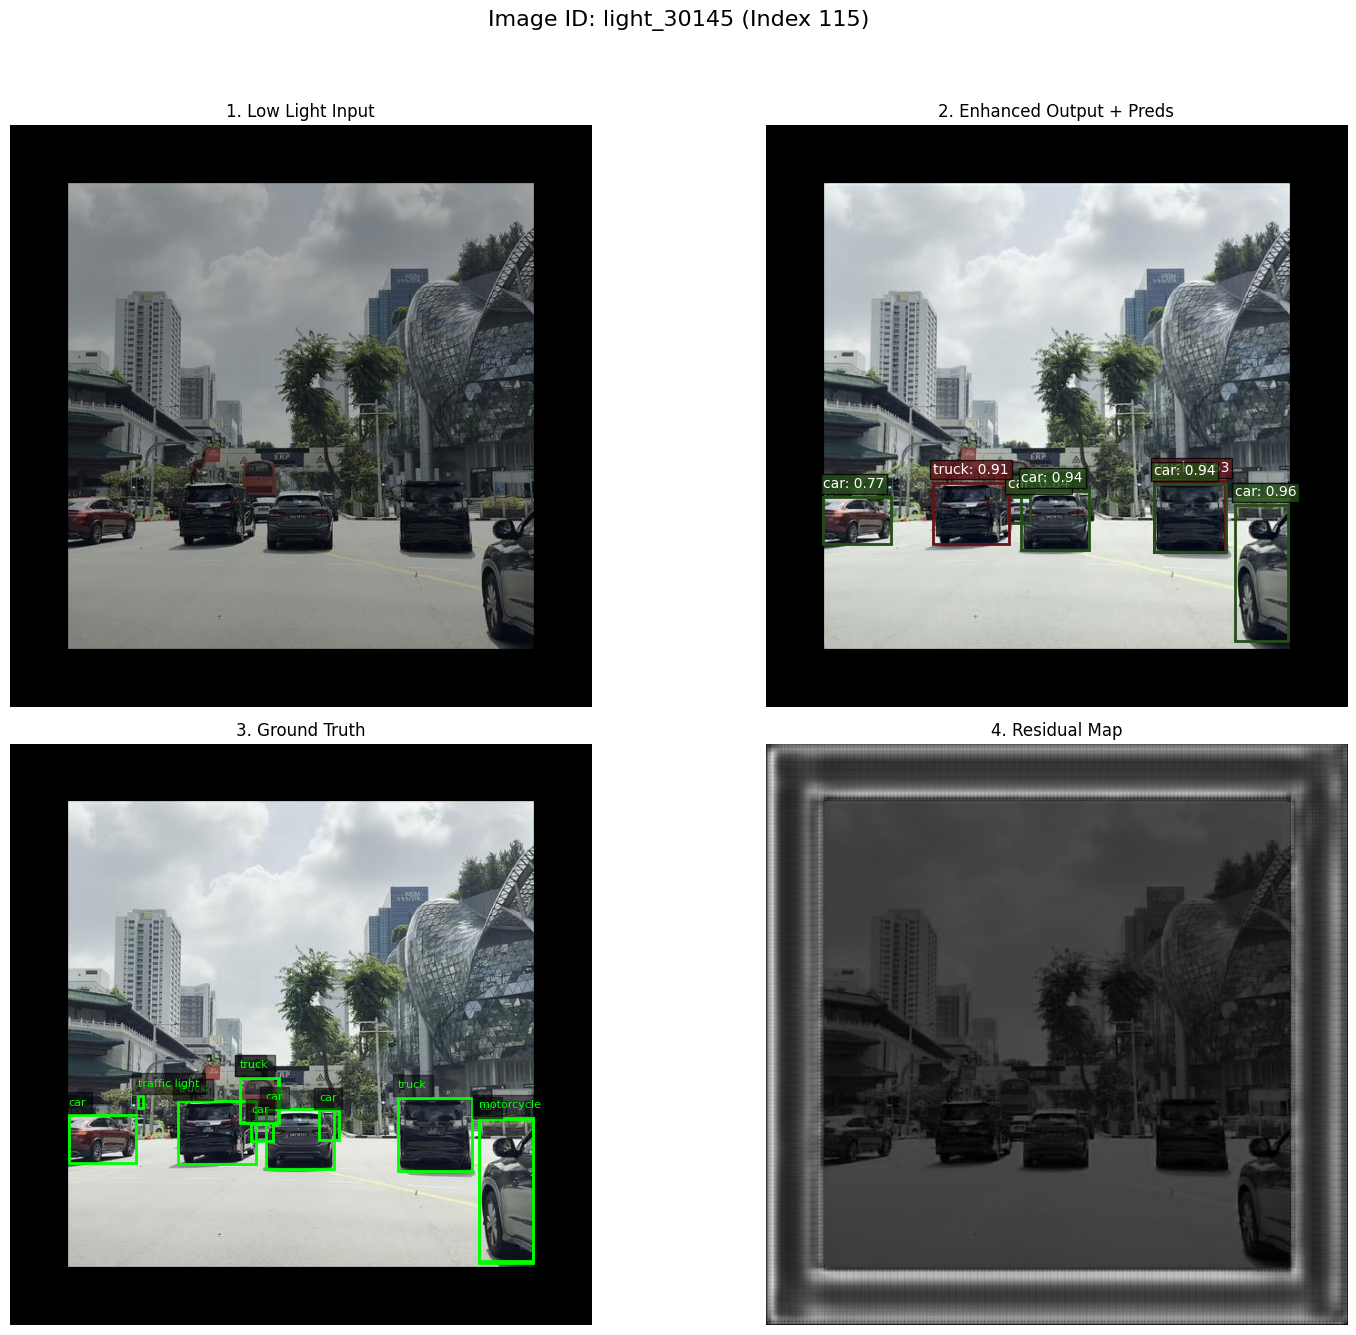

In [ ]:
from torchvision.ops import box_iou

# 1. Define Robust Precision/Recall Helper
def compute_precision_recall_robust(detections, gt_boxes, iou_thresh=0.5):
    """
    Robust calculation of P/R that handles empty or single-item tensors correctly.
    """
    # A. Prepare Prediction Boxes
    if len(detections) == 0:
        pred_boxes = torch.empty((0, 4))
    else:
        # Convert supervision numpy -> torch
        pred_boxes = torch.from_numpy(detections.xyxy).float()

    # B. Prepare GT Boxes
    gt_boxes = gt_boxes.cpu().float()
    pred_boxes = pred_boxes.cpu()

    # C. SAFETY: Force 2D shapes [N, 4] to prevent box_iou crash on single boxes
    if pred_boxes.dim() == 1: 
        pred_boxes = pred_boxes.unsqueeze(0)
    if gt_boxes.dim() == 1: 
        gt_boxes = gt_boxes.unsqueeze(0)

    # D. Edge Cases (Empty inputs)
    if len(gt_boxes) == 0:
        # If no GT, but we have preds -> Precision 0, Recall 0 (technically undefined)
        # If no GT, and no preds -> Perfect (1.0)
        return (0.0, 0.0) if len(pred_boxes) > 0 else (1.0, 1.0)
    
    if len(pred_boxes) == 0:
        # GT exists, but no preds -> Precision 0, Recall 0
        return 0.0, 0.0

    # E. Calculate IoU
    # box_iou requires (N,4) inputs
    ious = box_iou(pred_boxes, gt_boxes) 

    # F. Compute Metrics (Simple Greedy Matching)
    
    # Precision: What % of Predictions matched a GT?
    # For each Pred, did it hit ANY GT?
    max_iou_per_pred, _ = ious.max(dim=1)
    tp = (max_iou_per_pred >= iou_thresh).sum().item()
    fp = len(pred_boxes) - tp
    precision = tp / (tp + fp + 1e-6)

    # Recall: What % of GTs were detected?
    # For each GT, was it hit by ANY Pred?
    max_iou_per_gt, _ = ious.max(dim=0)
    tp_gt = (max_iou_per_gt >= iou_thresh).sum().item()
    fn = len(gt_boxes) - tp_gt
    recall = tp_gt / (tp_gt + fn + 1e-6)

    return precision, recall

def inference_visualization_mpl(model: torch.nn.Module, test_loader: torch.utils.data.DataLoader, class_names: dict):
    """
    Runs model inference, applies detection post-processing, and visualizes the 4 outputs 
    using a single Matplotlib figure with 4 subplots.
    """
    
    model.eval()
    device = next(model.parameters()).device
    
    print(f"--- Starting Visualization on Device: {device} ---")
    test_pbar = tqdm(test_loader, desc="Visualizing", leave=False)
    
    # Simple color map for visualization
    def get_color(cls_id, N): 
        # Generates a distinct color based on class ID
        r = (cls_id * 3 % 7 * 32 + 100) % 255 / 255.0
        g = (cls_id * 5 % 9 * 28 + 50) % 255 / 255.0
        b = (cls_id * 7 % 5 * 51 + 75) % 255 / 255.0
        return (r, g, b)

    def tensor_to_mpl(t: torch.Tensor) -> np.ndarray:
        # Clamp to [0, 1], move to CPU, HWC format (RGB) for Matplotlib
        return t.clamp(0, 1).cpu().numpy().transpose(1, 2, 0)

    with torch.no_grad():
        for batch_idx, batch_data in enumerate(test_pbar):
            
            low_imgs = batch_data['images_low'].to(device)
            
            # --- Model Forward Pass (Inference=True) ---
            det_out, llie_out, llie_residuals = model(low_imgs, inference=True)
            
            # --- Process Batch Image by Image ---
            for i in range(det_out.size(0)):
                
                # A. Detection Post-Processing
                
                # 1. Transpose to [N_boxes, C_data]
                preds_i = det_out[i].transpose(0, 1).contiguous() 

                # 2. Extract components
                boxes_xywh = preds_i[:, :4] # Model output is xywh
                cls_probs = preds_i[:, 4:]   # Class scores

                # 3. Get confidences and class indices
                confidences, class_indices = torch.max(cls_probs, dim=1)
                
                # 4. Convert coordinates
                boxes_xyxy = xywh2xyxy_tensor(boxes_xywh) 
                
                # 5. Filter by threshold
                CONF_THRESH = 0.75
                mask = confidences > CONF_THRESH
                
                if not mask.any(): 
                    detections = Detections.empty()
                else:
                    # 6. Create the final tensor [xyxy, conf, cls]
                    final_preds = torch.cat((
                        boxes_xyxy[mask], 
                        confidences[mask].unsqueeze(1), 
                        class_indices[mask].float().unsqueeze(1)
                    ), dim=1)
                    
                    # 7. Create Detections object
                    detections = Detections.from_yolo(final_preds)
                
                # B. Post-Processing: Rescale Boxes
                if len(detections) > 0:
                    detections = detections.with_nms(threshold=0.5)

                # C. Prepare Images for Display
                img_low_mpl = tensor_to_mpl(low_imgs[i])
                img_enhanced_mpl = tensor_to_mpl(llie_out[i])
                img_gt_mpl = tensor_to_mpl(batch_data['images_high'][i])
                residual_map = llie_residuals[i].mean(dim=0, keepdim=True).abs() 
                residual_vis_mpl = tensor_to_mpl(residual_map.repeat(3, 1, 1))

                # D. Visualization Plotting
                fig = plt.figure(figsize=(16, 14))
                fig.suptitle(f"Batch {batch_idx}, Image {i} Visualization", fontsize=16)
                
                # --- Plot 1: Low Light Input ---
                ax1 = fig.add_subplot(2, 2, 1)
                ax1.imshow(img_low_mpl)
                ax1.set_title('1. Low Light Input (I)')
                ax1.axis('off')
                
                # --- Plot 2: Enhanced Output with Detections ---
                ax2 = fig.add_subplot(2, 2, 2)
                ax2.imshow(img_enhanced_mpl)
                ax2.set_title('2. Enhanced Output (R) + Detections')
                ax2.axis('off')
                
                # Draw boxes on ax2
                if len(detections) > 0:
                    for box, _, conf, cls, _ in detections:
                        x1, y1, x2, y2 = box.astype(int)
                        
                        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, 
                                                 linewidth=2, 
                                                 edgecolor=get_color(int(cls), len(class_names)), 
                                                 facecolor='none')
                        ax2.add_patch(rect)
                        
                        label = f'{class_names.get(int(cls), "Unknown")}: {conf:.2f}'
                        ax2.text(x1, y1 - 10, label, color='white', 
                                 bbox={'facecolor': get_color(int(cls), len(class_names)), 
                                       'alpha': 0.8, 'pad': 2, 'edgecolor': 'none'})
                
                # --- Plot 3: Ground Truth High Light (G) ---
                ax3 = fig.add_subplot(2, 2, 3)
                ax3.imshow(img_gt_mpl)
                ax3.set_title('3. Ground Truth High Light (G)')
                ax3.axis('off')
                
                # --- NEW: PREPARE AND DRAW GT BOXES ---
                
                # 1. Setup variables
                all_batch_indices = batch_data['batch_idx'].to(device)
                all_bboxes = batch_data['bboxes'].to(device)
                all_cls = batch_data['cls'].to(device)
                
                mask_i = (all_batch_indices == i)
                gt_bboxes_xywh = all_bboxes[mask_i]
                gt_cls = all_cls[mask_i]
                
                pads = batch_data["padding_high"][i]
                
                # Define padded_image specifically for this loop iteration
                padded_image = batch_data['images_high'][i]
                padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]

                # Initialize empty GT tensor on DEVICE
                gt_boxes_xyxy = torch.empty((0, 4), device=device)

                if gt_bboxes_xywh.numel() > 0:
                    # Convert normalized xywh -> absolute xyxy in PADDED space
                    boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
                    boxes_abs[:, [0, 2]] *= padded_w
                    boxes_abs[:, [1, 3]] *= padded_h
                    
                    gt_boxes_xyxy = boxes_abs

                    # Draw boxes on Matplotlib
                    for j, box in enumerate(boxes_abs):
                        x1, y1, x2, y2 = box.int().tolist()
                        
                        rect = patches.Rectangle(
                            (x1, y1), x2 - x1, y2 - y1,
                            linewidth=2, edgecolor='lime', facecolor='none'
                        )
                        ax3.add_patch(rect)

                        cls_name = class_names.get(int(gt_cls[j]), "GT")
                        ax3.text(
                            x1, y1 - 10, cls_name,
                            color='lime', fontsize=8,
                            bbox={'facecolor': 'black', 'alpha': 0.5, 'pad': 2}
                        )
                
                # --- Plot 4: Residual Map (R - I) ---
                ax4 = fig.add_subplot(2, 2, 4)
                ax4.imshow(residual_vis_mpl)
                ax4.set_title('4. LLIE Residual Map (Magnitude)')
                ax4.axis('off')

                # --- Compute image metrics ---
                
                # Move GT image to DEVICE for PSNR/SSIM
                gt_image = batch_data['images_high'][i].to(device)

                img_psnr = psnr(
                    llie_out[i].unsqueeze(0),
                    gt_image.unsqueeze(0)
                ).item()

                img_ssim = ssim_metric(llie_out[i], gt_image)

                # *** FIX: Move GT boxes to CPU for compatibility with Detections (which are CPU/Numpy) ***
                precision_i, recall_i = compute_precision_recall(detections, gt_boxes_xyxy.cpu())
                map50_i = precision_i * recall_i 

                print(f"\n=== METRICS FOR THIS IMAGE ===")
                print(f"PSNR      : {img_psnr:.2f} dB")
                print(f"SSIM      : {img_ssim:.4f}")
                print(f"Precision : {precision_i:.3f}")
                print(f"Recall    : {recall_i:.3f}")
                print(f"mAP@50    : {map50_i:.3f}")

                plt.tight_layout(rect=[0, 0.03, 1, 0.95])
                plt.show() 
                
                # Stop after one image
                if batch_idx >= 0 and i >= 0: 
                    break 
            
            # Stop after one batch
            if batch_idx == 0:
                break 
                  
    print("--- Visualization Complete ---")

def visualize_random_sample(model: torch.nn.Module, test_loader: torch.utils.data.DataLoader, class_names: dict, rand_idx):
    """
    Picks ONE random image from the dataset, runs inference, and visualizes the result.
    """
    
    model.eval()
    device = next(model.parameters()).device
    dataset = test_loader.dataset
    
    # 1. Pick a Random Index
    # rand_idx = random.randint(0, len(dataset) - 1)
    print(f"--- Visualizing Random Sample Index: {rand_idx} ---")

    # 2. Fetch the single sample and Collate it into a batch of size 1
    # We use the loader's own collate_fn to ensure data structure matches exactly
    single_sample = dataset[rand_idx]
    batch_data = test_loader.collate_fn([single_sample])

    # 3. Simple color map & Helper
    def get_color(cls_id, N): 
        r = (cls_id * 3 % 7 * 32 + 100) % 255 / 255.0
        g = (cls_id * 5 % 9 * 28 + 50) % 255 / 255.0
        b = (cls_id * 7 % 5 * 51 + 75) % 255 / 255.0
        return (r, g, b)

    def tensor_to_mpl(t: torch.Tensor) -> np.ndarray:
        return t.clamp(0, 1).cpu().numpy().transpose(1, 2, 0)

    with torch.no_grad():
        # Move inputs to device
        low_imgs = batch_data['images_low'].to(device)
        
        # --- Model Forward Pass ---
        det_out, llie_out, llie_residuals = model(low_imgs, inference=True)
        
        # We know batch size is 1, so i is always 0
        i = 0 
        
        # A. Detection Post-Processing
        preds_i = det_out[i].transpose(0, 1).contiguous() 
        boxes_xywh = preds_i[:, :4]
        cls_probs = preds_i[:, 4:]  
        confidences, class_indices = torch.max(cls_probs, dim=1)
        
        boxes_xyxy = xywh2xyxy_tensor(boxes_xywh) 
        
        CONF_THRESH = 0.50 # You can adjust this
        mask = confidences > CONF_THRESH
        
        if not mask.any(): 
            detections = Detections.empty()
            print("No detections above threshold.")
        else:
            final_preds = torch.cat((
                boxes_xyxy[mask], 
                confidences[mask].unsqueeze(1), 
                class_indices[mask].float().unsqueeze(1)
            ), dim=1)
            detections = Detections.from_yolo(final_preds).with_nms(threshold=0.5)

        # B. Prepare Images
        img_low_mpl = tensor_to_mpl(low_imgs[i])
        img_enhanced_mpl = tensor_to_mpl(llie_out[i])
        img_gt_mpl = tensor_to_mpl(batch_data['images_high'][i])
        residual_map = llie_residuals[i].mean(dim=0, keepdim=True).abs() 
        residual_vis_mpl = tensor_to_mpl(residual_map.repeat(3, 1, 1))

        # C. Visualization Plotting
        fig = plt.figure(figsize=(16, 14))
        img_name = batch_data['im_id'][i]
        fig.suptitle(f"Image ID: {img_name} (Index {rand_idx})", fontsize=16)
        
        # Plot 1: Low Light
        ax1 = fig.add_subplot(2, 2, 1)
        ax1.imshow(img_low_mpl)
        ax1.set_title('1. Low Light Input')
        ax1.axis('off')
        
        # Plot 2: Enhanced + Detections
        ax2 = fig.add_subplot(2, 2, 2)
        ax2.imshow(img_enhanced_mpl)
        ax2.set_title('2. Enhanced Output + Preds')
        ax2.axis('off')
        
        if len(detections) > 0:
            for box, _, conf, cls, _ in detections:
                x1, y1, x2, y2 = box.astype(int)
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, 
                                         edgecolor=get_color(int(cls), len(class_names)), facecolor='none')
                ax2.add_patch(rect)
                label = f'{class_names.get(int(cls), "Unknown")}: {conf:.2f}'
                ax2.text(x1, y1 - 10, label, color='white', 
                         bbox={'facecolor': get_color(int(cls), len(class_names)), 'alpha': 0.8, 'pad': 2})
        
        # Plot 3: Ground Truth
        ax3 = fig.add_subplot(2, 2, 3)
        ax3.imshow(img_gt_mpl)
        ax3.set_title('3. Ground Truth')
        ax3.axis('off')
        
        # --- GT BOX LOGIC ---
        all_indices = batch_data['batch_idx'].to(device)
        all_bboxes = batch_data['bboxes'].to(device)
        all_cls = batch_data['cls'].to(device)
        
        mask_i = (all_indices == i) # Should be all True since batch size is 1
        gt_bboxes_xywh = all_bboxes[mask_i]
        gt_cls = all_cls[mask_i]
        
        padded_image = batch_data['images_high'][i]
        padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]
        
        gt_boxes_xyxy = torch.empty((0, 4), device=device)

        if gt_bboxes_xywh.numel() > 0:
            boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
            boxes_abs[:, [0, 2]] *= padded_w
            boxes_abs[:, [1, 3]] *= padded_h
            gt_boxes_xyxy = boxes_abs

            for j, box in enumerate(boxes_abs):
                x1, y1, x2, y2 = box.int().tolist()
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='lime', facecolor='none')
                ax3.add_patch(rect)
                cls_name = class_names.get(int(gt_cls[j]), "GT")
                ax3.text(x1, y1 - 10, cls_name, color='lime', fontsize=8, bbox={'facecolor': 'black', 'alpha': 0.5})

        # Plot 4: Residual
        ax4 = fig.add_subplot(2, 2, 4)
        ax4.imshow(residual_vis_mpl)
        ax4.set_title('4. Residual Map')
        ax4.axis('off')

        # D. Metrics
        gt_image = batch_data['images_high'][i].to(device)
        img_psnr = psnr(llie_out[i].unsqueeze(0), gt_image.unsqueeze(0)).item()
        img_ssim = ssim_metric(llie_out[i], gt_image)
        if isinstance(img_ssim, torch.Tensor): img_ssim = img_ssim.item()
        
        # Robust Precision/Recall using the fixed function from before
        precision_i, recall_i = compute_precision_recall_robust(detections, gt_boxes_xyxy.cpu())
        map50_i = precision_i * recall_i 
        
        print(f"\n=== METRICS: Image {rand_idx} ===")
        print(f"PSNR      : {img_psnr:.2f}")
        print(f"SSIM      : {img_ssim:.4f}")
        print(f"Precision : {precision_i:.3f}")
        print(f"Recall    : {recall_i:.3f}")
        print(f"mAP@50    : {map50_i:.3f}")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Usage:
# visualize_random_sample(model, test_loader, CLASSES_TO_DETECT)
model = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=True)

checkpoint_path = 'best_backDef_decARB_composite.pt'
# checkpoint_path = r'ok\best_default_illuminet_composite.pt'
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    # Case A: You saved {'epoch': ..., 'model_state_dict': ...}
    print("Loading from full checkpoint dictionary...")
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    # Case B: You saved model.state_dict() directly
    print("Loading direct state dictionary...")
    model.load_state_dict(checkpoint)

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print("Model loaded successfully!")

CLASSES_TO_DETECT = load_classes_as_dict(CLASSES_FILE)
# inference_visualization_mpl(model=model, test_loader=test_loader, class_names=CLASSES_TO_DETECT)
visualize_random_sample(model=model, test_loader=test_loader, class_names=CLASSES_TO_DETECT, rand_idx=115)

In [ ]:
def visualize_random_sample(model: torch.nn.Module, test_loader: torch.utils.data.DataLoader, class_names: dict):
    """
    Picks ONE random image from the dataset, runs inference, and visualizes the result.
    """
    
    model.eval()
    device = next(model.parameters()).device
    dataset = test_loader.dataset
    
    # 1. Pick a Random Index
    rand_idx = random.randint(0, len(dataset) - 1)
    print(f"--- Visualizing Random Sample Index: {rand_idx} ---")

    # 2. Fetch the single sample and Collate it into a batch of size 1
    # We use the loader's own collate_fn to ensure data structure matches exactly
    single_sample = dataset[rand_idx]
    batch_data = test_loader.collate_fn([single_sample])

    # 3. Simple color map & Helper
    def get_color(cls_id, N): 
        r = (cls_id * 3 % 7 * 32 + 100) % 255 / 255.0
        g = (cls_id * 5 % 9 * 28 + 50) % 255 / 255.0
        b = (cls_id * 7 % 5 * 51 + 75) % 255 / 255.0
        return (r, g, b)

    def tensor_to_mpl(t: torch.Tensor) -> np.ndarray:
        return t.clamp(0, 1).cpu().numpy().transpose(1, 2, 0)

    with torch.no_grad():
        # Move inputs to device
        low_imgs = batch_data['images_low'].to(device)
        
        # --- Model Forward Pass ---
        det_out, llie_out, llie_residuals = model(low_imgs, inference=True)
        
        # We know batch size is 1, so i is always 0
        i = 0 
        
        # A. Detection Post-Processing
        preds_i = det_out[i].transpose(0, 1).contiguous() 
        boxes_xywh = preds_i[:, :4]
        cls_probs = preds_i[:, 4:]  
        confidences, class_indices = torch.max(cls_probs, dim=1)
        
        boxes_xyxy = xywh2xyxy_tensor(boxes_xywh) 
        
        CONF_THRESH = 0.50 # You can adjust this
        mask = confidences > CONF_THRESH
        
        if not mask.any(): 
            detections = Detections.empty()
            print("No detections above threshold.")
        else:
            final_preds = torch.cat((
                boxes_xyxy[mask], 
                confidences[mask].unsqueeze(1), 
                class_indices[mask].float().unsqueeze(1)
            ), dim=1)
            detections = Detections.from_yolo(final_preds).with_nms(threshold=0.5)

        # B. Prepare Images
        img_low_mpl = tensor_to_mpl(low_imgs[i])
        img_enhanced_mpl = tensor_to_mpl(llie_out[i])
        img_gt_mpl = tensor_to_mpl(batch_data['images_high'][i])
        residual_map = llie_residuals[i].mean(dim=0, keepdim=True).abs() 
        residual_vis_mpl = tensor_to_mpl(residual_map.repeat(3, 1, 1))

        # C. Visualization Plotting
        fig = plt.figure(figsize=(16, 14))
        img_name = batch_data['im_id'][i]
        fig.suptitle(f"Image ID: {img_name} (Index {rand_idx})", fontsize=16)
        
        # Plot 1: Low Light
        ax1 = fig.add_subplot(2, 2, 1)
        ax1.imshow(img_low_mpl)
        ax1.set_title('1. Low Light Input')
        ax1.axis('off')
        
        # Plot 2: Enhanced + Detections
        ax2 = fig.add_subplot(2, 2, 2)
        ax2.imshow(img_enhanced_mpl)
        ax2.set_title('2. Enhanced Output + Preds')
        ax2.axis('off')
        
        if len(detections) > 0:
            for box, _, conf, cls, _ in detections:
                x1, y1, x2, y2 = box.astype(int)
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, 
                                         edgecolor=get_color(int(cls), len(class_names)), facecolor='none')
                ax2.add_patch(rect)
                label = f'{class_names.get(int(cls), "Unknown")}: {conf:.2f}'
                ax2.text(x1, y1 - 10, label, color='white', 
                         bbox={'facecolor': get_color(int(cls), len(class_names)), 'alpha': 0.8, 'pad': 2})
        
        # Plot 3: Ground Truth
        ax3 = fig.add_subplot(2, 2, 3)
        ax3.imshow(img_gt_mpl)
        ax3.set_title('3. Ground Truth')
        ax3.axis('off')
        
        # --- GT BOX LOGIC ---
        all_indices = batch_data['batch_idx'].to(device)
        all_bboxes = batch_data['bboxes'].to(device)
        all_cls = batch_data['cls'].to(device)
        
        mask_i = (all_indices == i) # Should be all True since batch size is 1
        gt_bboxes_xywh = all_bboxes[mask_i]
        gt_cls = all_cls[mask_i]
        
        padded_image = batch_data['images_high'][i]
        padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]
        
        gt_boxes_xyxy = torch.empty((0, 4), device=device)

        if gt_bboxes_xywh.numel() > 0:
            boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
            boxes_abs[:, [0, 2]] *= padded_w
            boxes_abs[:, [1, 3]] *= padded_h
            gt_boxes_xyxy = boxes_abs

            for j, box in enumerate(boxes_abs):
                x1, y1, x2, y2 = box.int().tolist()
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='lime', facecolor='none')
                ax3.add_patch(rect)
                cls_name = class_names.get(int(gt_cls[j]), "GT")
                ax3.text(x1, y1 - 10, cls_name, color='lime', fontsize=8, bbox={'facecolor': 'black', 'alpha': 0.5})

        # Plot 4: Residual
        ax4 = fig.add_subplot(2, 2, 4)
        ax4.imshow(residual_vis_mpl)
        ax4.set_title('4. Residual Map')
        ax4.axis('off')

        # D. Metrics
        gt_image = batch_data['images_high'][i].to(device)
        img_psnr = psnr(llie_out[i].unsqueeze(0), gt_image.unsqueeze(0)).item()
        img_ssim = ssim_metric(llie_out[i], gt_image)
        if isinstance(img_ssim, torch.Tensor): img_ssim = img_ssim.item()
        
        # Robust Precision/Recall using the fixed function from before
        precision_i, recall_i = compute_precision_recall_robust(detections, gt_boxes_xyxy.cpu())
        
        print(f"\n=== METRICS: Image {rand_idx} ===")
        print(f"PSNR      : {img_psnr:.2f}")
        print(f"SSIM      : {img_ssim:.4f}")
        print(f"Precision : {precision_i:.3f}")
        print(f"Recall    : {recall_i:.3f}")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Usage:
# visualize_random_sample(model, test_loader, CLASSES_TO_DETECT)

In [ ]:
class ModelEvaluator:
    def __init__(self, test_loader, device):
        self.test_loader = test_loader
        self.device = device
    
    def evaluate(self, model, weight_path, model_name="Unknown"):
        # 1. Load Weights
        print(f"Loading weights for {model_name} from: {weight_path}")
        try:
            checkpoint = torch.load(weight_path, map_location=self.device)
            # Handle if weights are in 'model_state_dict' or just the dict directly
            state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
            model.load_state_dict(state_dict)
        except Exception as e:
            print(f"Error loading {weight_path}: {e}")
            return None

        model.to(self.device)
        model.eval()
        
        # Metrics Accumulators
        metrics = {
            'psnr': [],
            'ssim': [],
            'precision': [],
            'recall': [],
            'map50': []
        }
        
        pbar = tqdm(self.test_loader, desc=f"Eval {model_name}", leave=True)
        
        with torch.no_grad():
            for batch_data in pbar:
                low_imgs = batch_data['images_low'].to(self.device)
                
                # Inference
                det_out, llie_out, _ = model(low_imgs, inference=True)
                
                # --- Per Image Processing in Batch ---
                for i in range(det_out.size(0)):
                    # ================================
                    # 1. IMAGE METRICS (PSNR / SSIM)
                    # ================================
                    gt_image = batch_data['images_high'][i].to(self.device)
                    enhanced_image = llie_out[i]
                    
                    # PSNR
                    val_psnr = psnr(enhanced_image.unsqueeze(0), gt_image.unsqueeze(0)).item()
                    metrics['psnr'].append(val_psnr)
                    
                    # SSIM
                    val_ssim = ssim_metric(enhanced_image, gt_image) # Assumes input is (C, H, W) or (1, C, H, W)
                    # Handle if ssim returns tensor
                    if isinstance(val_ssim, torch.Tensor):
                        val_ssim = val_ssim.item()
                    metrics['ssim'].append(val_ssim)

                    # ================================
                    # 2. DETECTION METRICS
                    # ================================
                    
                    # --- PREPARE PREDICTIONS ---
                    preds_i = det_out[i].transpose(0, 1).contiguous()
                    boxes_xywh = preds_i[:, :4]
                    cls_probs = preds_i[:, 4:]
                    confidences, class_indices = torch.max(cls_probs, dim=1)
                    
                    boxes_xyxy = xywh2xyxy_tensor(boxes_xywh)
                    
                    CONF_THRESH = 0.50 # Standard eval threshold, adjust if needed
                    mask = confidences > CONF_THRESH
                    
                    if not mask.any():
                        detections = Detections.empty()
                    else:
                        final_preds = torch.cat((
                            boxes_xyxy[mask], 
                            confidences[mask].unsqueeze(1), 
                            class_indices[mask].float().unsqueeze(1)
                        ), dim=1)
                        detections = Detections.from_yolo(final_preds)
                        detections = detections.with_nms(threshold=0.5)

                    # --- PREPARE GROUND TRUTH ---
                    all_indices = batch_data['batch_idx'].to(self.device)
                    all_bboxes = batch_data['bboxes'].to(self.device)
                    all_cls = batch_data['cls'].to(self.device)
                    
                    # Filter for current image
                    mask_i = (all_indices == i)
                    gt_bboxes_xywh = all_bboxes[mask_i]
                    
                    padded_image = batch_data['images_high'][i]
                    padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]
                    
                    gt_boxes_xyxy = torch.empty((0, 4), device=self.device)
                    
                    if gt_bboxes_xywh.numel() > 0:
                        # Normalize -> Absolute Padded Coordinates
                        boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
                        boxes_abs[:, [0, 2]] *= padded_w
                        boxes_abs[:, [1, 3]] *= padded_h
                        gt_boxes_xyxy = boxes_abs

                    # --- COMPUTE DETECTION METRICS ---
                    # Move to CPU for compatibility if using supervision or numpy based IoU
                    prec, rec = compute_precision_recall(detections, gt_boxes_xyxy.cpu())
                    
                    metrics['precision'].append(prec)
                    metrics['recall'].append(rec)
                    metrics['map50'].append(prec * rec) # Simple mAP estimation

        # Calculate Averages
        summary = {k: np.mean(v) for k, v in metrics.items()}
        print(f"Results {model_name}: {summary}")
        return summary

model_weight_paths = {
    "default_final": 'final_default_illuminet_epoch40.pt',
    'default_best': 'best_default_illuminet_composite.pt',
    
    'backARB_decDef_final':  'final_backARB_decDef_epoch40.pt',
    'backARB_decDef_best' : 'best_backARB_decDef_composite.pt',
    
    'backDef_decARB_final' : 'final_backDef_decARB_epoch40.pt',
    'backDef_decARB_best' : 'best_backDef_decARB_composite.pt',
    
    'bothARB_final' : 'final_backARB_decARB_epoch40.pt',
    'bothARB_best' : 'best_backARB_decARB_composite.pt'
}

default_mod = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=False)
backARB_decDef_mod = IllumiNet_b5_ARB(back_use_arb=True, dec_arb=False)
backDef_decARB_mod = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=True)
bothARB_mod = IllumiNet_b5_ARB(back_use_arb=True, dec_arb=True)


configurations = [
    ("Default (Final)",       default_mod,        "default_final"),
    ("Default (Best)",        default_mod,        "default_best"),
    
    ("BackARB (Final)",       backARB_decDef_mod, "backARB_decDef_final"),
    ("BackARB (Best)",        backARB_decDef_mod, "backARB_decDef_best"),
    
    ("DecARB (Final)",        backDef_decARB_mod, "backDef_decARB_final"),
    ("DecARB (Best)",         backDef_decARB_mod, "backDef_decARB_best"),
    
    ("BothARB (Final)",       bothARB_mod,        "bothARB_final"),
    ("BothARB (Best)",        bothARB_mod,        "bothARB_best"),
]

# 5. Run Evaluation Loop
evaluator = ModelEvaluator(test_loader, device)
results_table = []

print("Starting Full Evaluation Benchmark...")
print("="*60)

for nice_name, model_obj, weight_key in configurations:
    weight_file = model_weight_paths.get(weight_key)
    
    if not weight_file:
        print(f"Skipping {nice_name}: Key {weight_key} not found in path dict.")
        continue
        
    # Run Eval
    res = evaluator.evaluate(model_obj, weight_file, model_name=nice_name)
    
    if res:
        res['Model'] = nice_name
        res['Weights'] = weight_file
        results_table.append(res)

# 6. Display Final DataFrame
print("\n" + "="*60)
print("FINAL BENCHMARK RESULTS")
print("="*60)

if results_table:
    df_results = pd.DataFrame(results_table)
    
    # Reorder columns for readability
    cols = ['Model', 'map50', 'precision', 'recall', 'psnr', 'ssim', 'Weights']
    df_results = df_results[cols]
    
    # Round for display
    print(df_results.round(4).to_string(index=False))
else:
    print("No results generated.")

Backbone ARB:  False
Decoder ARB False
Initializing nano params
NO ARB in Backbone
Night Dec initalized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Backbone ARB:  True
Decoder ARB False
Initializing nano params
ARB Backbone Initialized


C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_6232\1770222224.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weight_path, map_locati

Night Dec initalized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Backbone ARB:  False
Decoder ARB True
Initializing nano params
NO ARB in Backbone
ARB LLIE Decoder Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Backbone ARB:  True
Decoder ARB True
Initializing nano params
ARB Backbone Initialized
ARB LLIE Decoder Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 

Eval Default (Final):   0%|          | 0/38 [00:00<?, ?it/s]

tensor([])
tensor([[ 8.],
        [ 8.],
        [ 8.],
        ...,
        [32.],
        [32.],
        [32.]], device='cuda:0')


...

Results Default (Best): {'psnr': np.float64(27.396660060882567), 'ssim': np.float32(0.92331654), 'precision': np.float64(0.8630275833526793), 'recall': np.float64(0.6578608090526171), 'map50': np.float64(0.572875701857229)}
Loading weights for BackARB (Final) from: final_backARB_decDef_epoch40.pt


Eval BackARB (Final):   0%|          | 0/38 [00:00<?, ?it/s]

tensor([])
tensor([[ 8.],
        [ 8.],
        [ 8.],
        ...,
        [32.],
        [32.],
        [32.]], device='cuda:0')


Eval BackARB (Final):  11%|█         | 4/38 [00:03<00:33,  1.03it/s]


IndexError: too many indices for tensor of dimension 1

In [ ]:
from torchvision.ops import box_iou

# 1. Define Robust Precision/Recall Helper
def compute_precision_recall_robust(detections, gt_boxes, iou_thresh=0.5):
    """
    Robust calculation of P/R that handles empty or single-item tensors correctly.
    """
    # A. Prepare Prediction Boxes
    if len(detections) == 0:
        pred_boxes = torch.empty((0, 4))
    else:
        # Convert supervision numpy -> torch
        pred_boxes = torch.from_numpy(detections.xyxy).float()

    # B. Prepare GT Boxes
    gt_boxes = gt_boxes.cpu().float()
    pred_boxes = pred_boxes.cpu()

    # C. SAFETY: Force 2D shapes [N, 4] to prevent box_iou crash on single boxes
    if pred_boxes.dim() == 1: 
        pred_boxes = pred_boxes.unsqueeze(0)
    if gt_boxes.dim() == 1: 
        gt_boxes = gt_boxes.unsqueeze(0)

    # D. Edge Cases (Empty inputs)
    if len(gt_boxes) == 0:
        # If no GT, but we have preds -> Precision 0, Recall 0 (technically undefined)
        # If no GT, and no preds -> Perfect (1.0)
        return (0.0, 0.0) if len(pred_boxes) > 0 else (1.0, 1.0)
    
    if len(pred_boxes) == 0:
        # GT exists, but no preds -> Precision 0, Recall 0
        return 0.0, 0.0

    # E. Calculate IoU
    # box_iou requires (N,4) inputs
    ious = box_iou(pred_boxes, gt_boxes) 

    # F. Compute Metrics (Simple Greedy Matching)
    
    # Precision: What % of Predictions matched a GT?
    # For each Pred, did it hit ANY GT?
    max_iou_per_pred, _ = ious.max(dim=1)
    tp = (max_iou_per_pred >= iou_thresh).sum().item()
    fp = len(pred_boxes) - tp
    precision = tp / (tp + fp + 1e-6)

    # Recall: What % of GTs were detected?
    # For each GT, was it hit by ANY Pred?
    max_iou_per_gt, _ = ious.max(dim=0)
    tp_gt = (max_iou_per_gt >= iou_thresh).sum().item()
    fn = len(gt_boxes) - tp_gt
    recall = tp_gt / (tp_gt + fn + 1e-6)

    return precision, recall


# 2. Model Evaluator Class
class ModelEvaluator:
    def __init__(self, test_loader, device):
        self.test_loader = test_loader
        self.device = device
    
    def evaluate(self, model, weight_path, model_name="Unknown"):
        print(f"Loading weights for {model_name} from: {weight_path}")
        try:
            checkpoint = torch.load(weight_path, map_location=self.device)
            state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
            model.load_state_dict(state_dict)
        except Exception as e:
            print(f"Error loading {weight_path}: {e}")
            return None

        model.to(self.device)
        model.eval()
        
        metrics = {'psnr': [], 'ssim': [], 'precision': [], 'recall': [], 'map50': []}
        
        pbar = tqdm(self.test_loader, desc=f"Eval {model_name}", leave=True)
        
        with torch.no_grad():
            for batch_data in pbar:
                low_imgs = batch_data['images_low'].to(self.device)
                
                # Inference
                det_out, llie_out, _ = model(low_imgs, inference=True)
                
                for i in range(det_out.size(0)):
                    # --- 1. Image Metrics ---
                    gt_image = batch_data['images_high'][i].to(self.device)
                    enhanced_image = llie_out[i]
                    
                    metrics['psnr'].append(psnr(enhanced_image.unsqueeze(0), gt_image.unsqueeze(0)).item())
                    
                    val_ssim = ssim_metric(enhanced_image, gt_image)
                    if isinstance(val_ssim, torch.Tensor): val_ssim = val_ssim.item()
                    metrics['ssim'].append(val_ssim)

                    # --- 2. Detection Metrics ---
                    preds_i = det_out[i].transpose(0, 1).contiguous()
                    boxes_xywh = preds_i[:, :4]
                    cls_probs = preds_i[:, 4:]
                    confidences, _ = torch.max(cls_probs, dim=1)
                    _, class_indices = torch.max(cls_probs, dim=1)
                    
                    boxes_xyxy = xywh2xyxy_tensor(boxes_xywh)
                    
                    mask = confidences > 0.50
                    
                    if not mask.any():
                        detections = Detections.empty()
                    else:
                        final_preds = torch.cat((
                            boxes_xyxy[mask], 
                            confidences[mask].unsqueeze(1), 
                            class_indices[mask].float().unsqueeze(1)
                        ), dim=1)
                        detections = Detections.from_yolo(final_preds).with_nms(threshold=0.5)

                    # GT Prep
                    all_indices = batch_data['batch_idx'].to(self.device)
                    all_bboxes = batch_data['bboxes'].to(self.device)
                    
                    mask_i = (all_indices == i)
                    gt_bboxes_xywh = all_bboxes[mask_i]
                    padded_image = batch_data['images_high'][i]
                    padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]
                    
                    gt_boxes_xyxy = torch.empty((0, 4), device=self.device)
                    if gt_bboxes_xywh.numel() > 0:
                        boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
                        boxes_abs[:, [0, 2]] *= padded_w
                        boxes_abs[:, [1, 3]] *= padded_h
                        gt_boxes_xyxy = boxes_abs

                    # USE ROBUST FUNC
                    prec, rec = compute_precision_recall_robust(detections, gt_boxes_xyxy.cpu())
                    
                    metrics['precision'].append(prec)
                    metrics['recall'].append(rec)
                    metrics['map50'].append(prec * rec)

        summary = {k: np.mean(v) for k, v in metrics.items()}
        print(f"Results {model_name}: {summary}")
        return summary

# 3. Run Benchmark
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Configurations
configurations = [
    ("Default (Final)",       default_mod,        "default_final"),
    ("Default (Best)",        default_mod,        "default_best"),
    ("BackARB (Final)",       backARB_decDef_mod, "backARB_decDef_final"),
    ("BackARB (Best)",        backARB_decDef_mod, "backARB_decDef_best"),
    ("DecARB (Final)",        backDef_decARB_mod, "backDef_decARB_final"),
    ("DecARB (Best)",         backDef_decARB_mod, "backDef_decARB_best"),
    ("BothARB (Final)",       bothARB_mod,        "bothARB_final"),
    ("BothARB (Best)",        bothARB_mod,        "bothARB_best"),
]

evaluator = ModelEvaluator(test_loader, device)
results_table = []

print("Starting Full Evaluation Benchmark...")
print("="*60)

for nice_name, model_obj, weight_key in configurations:
    weight_file = model_weight_paths.get(weight_key)
    if not weight_file: continue
        
    res = evaluator.evaluate(model_obj, weight_file, model_name=nice_name)
    if res:
        res['Model'] = nice_name
        res['Weights'] = weight_file
        results_table.append(res)

print("\n" + "="*60)
print("FINAL BENCHMARK RESULTS")
print("="*60)
if results_table:
    df_results = pd.DataFrame(results_table)
    cols = ['Model', 'map50', 'precision', 'recall', 'psnr', 'ssim', 'Weights']
    print(df_results[cols].round(4).to_string(index=False))

C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_6232\573950340.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weight_path, map_locatio

Starting Full Evaluation Benchmark...
Loading weights for Default (Final) from: final_default_illuminet_epoch40.pt


Eval Default (Final):   0%|          | 0/38 [00:00<?, ?it/s]

tensor([[ 8.,  8.,  8.,  ..., 32., 32., 32.]], device='cuda:0')
tensor([[ 8.],
        [ 8.],
        [ 8.],
        ...,
        [32.],
        [32.],
        [32.]], device='cuda:0')


Eval Default (Final):  97%|█████████▋| 37/38 [00:28<00:00,  1.28it/s]

...

tensor([[ 8.,  8.,  8.,  ..., 32., 32., 32.]], device='cuda:0')
tensor([[ 8.],
        [ 8.],
        [ 8.],
        ...,
        [32.],
        [32.],
        [32.]], device='cuda:0')


Eval BothARB (Best):  97%|█████████▋| 37/38 [00:31<00:00,  1.16it/s]

tensor([[ 8.,  8.,  8.,  ..., 32., 32., 32.]], device='cuda:0')
tensor([[ 8.],
        [ 8.],
        [ 8.],
        ...,
        [32.],
        [32.],
        [32.]], device='cuda:0')


Eval BothARB (Best): 100%|██████████| 38/38 [00:32<00:00,  1.18it/s]

Results BothARB (Best): {'psnr': np.float64(29.007884038289387), 'ssim': np.float32(0.9153547), 'precision': np.float64(0.9318967809185259), 'recall': np.float64(0.5953037496972453), 'map50': np.float64(0.5652837966132601)}

FINAL BENCHMARK RESULTS
          Model  map50  precision  recall    psnr   ssim                             Weights
Default (Final) 0.6135     0.8751  0.6964 28.0502 0.9253  final_default_illuminet_epoch40.pt
 Default (Best) 0.6085     0.8630  0.7010 27.3967 0.9233 best_default_illuminet_composite.pt
BackARB (Final) 0.6047     0.8737  0.6796 29.6592 0.9304     final_backARB_decDef_epoch40.pt
 BackARB (Best) 0.5998     0.8692  0.6772 29.7199 0.9305    best_backARB_decDef_composite.pt
 DecARB (Final) 0.6174     0.8725  0.6967 30.2373 0.9314     final_backDef_decARB_epoch40.pt
  DecARB (Best) 0.6117     0.8709  0.6907 30.2502 0.9311    best_backDef_decARB_composite.pt
BothARB (Final) 0.6012     0.8729  0.6734 30.0912 0.9314     final_backARB_decARB_epoch40.pt
 BothAR